# Evaluation & Error Analysis

*Does this model clear the bar for production — and where, specifically, does it still fail?*

This is the one point in the project where the sealed test set opens: 1,409 customers held back
since the very first data split, untouched by feature engineering, training, tuning, and
calibration. `models/evaluate.py` scored them once; `models/error_analysis.py` diagnosed the
resulting errors. **This notebook only displays what those two scripts already produced — it
computes nothing new.** No model is loaded, no SHAP value is computed, and no test-set row is read
here — keeping that scoring a one-time event is what keeps every number below trustworthy.

The one thing only a person can do: weigh the diagnostics below — what automation can flag but
never judge — and record an approve/reject verdict, stamped in the closing cell (Section 8). That
verdict is what `models/register.py` requires before the model is promoted.

In [1]:
%matplotlib inline

from __future__ import annotations

import base64
import json
import os
import warnings
from datetime import datetime, timezone

warnings.filterwarnings("ignore")

import mlflow
import mlflow.tracking
import pandas as pd
from dotenv import load_dotenv
from IPython.display import HTML, Image, display

load_dotenv()

from telco_churn.models.error_analysis import display_feature_name
from telco_churn.models.gate import record_review
from telco_churn.utils.logging import configure_logging
from telco_churn.utils.mlflow import resolve_tracking_uri
from telco_churn.utils.paths import get_project_root

configure_logging()
mlflow.set_tracking_uri(
    resolve_tracking_uri(os.environ.get("MLFLOW_TRACKING_URI", "sqlite:///mlflow.db"))
)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

reports_dir = get_project_root() / "reports"
figures_dir = reports_dir / "figures"

## 1. Load the sealed-test evaluation and error-analysis artifacts

### The four artifacts loaded below

`metrics.json` holds the headline sealed-test metrics and the disaggregated slices behind
Section 5; `economics.json` the business-impact detail behind Section 4; `promotion_decision.json`
the gate's verdict (Section 2); `error_analysis.json` the error diagnosis behind Sections 6–8.
Together they are the complete record of this evaluation cycle — nothing on this page is
re-derived from `reports/test_predictions.parquet` or `reports/dev_oof_predictions.parquet`
directly.

In [2]:
with open(reports_dir / "metrics.json", encoding="utf-8") as f:
    metrics = json.load(f)
with open(reports_dir / "economics.json", encoding="utf-8") as f:
    economics = json.load(f)
with open(reports_dir / "promotion_decision.json", encoding="utf-8") as f:
    promotion_decision = json.load(f)
with open(reports_dir / "error_analysis.json", encoding="utf-8") as f:
    error_analysis = json.load(f)

print(f"Model version evaluated : {metrics['model_version']}  (run_id={metrics['run_id']})")
print(f"Champion at evaluation  : {metrics['champion_version'] or '(none — cold start)'}")
print(f"Gate regime             : {promotion_decision['regime']}")
print(f"Gate result             : {promotion_decision['gate']}")

Model version evaluated : 2  (run_id=2f168483000e45a7b8c0a16ff68b4064)
Champion at evaluation  : (none — cold start)
Gate regime             : cold_start
Gate result             : pass


## 2. The four promotion-gate criteria

`models/gate.py::decide_promotion` computes this the moment the sealed-test metrics exist, and it
is deliberately narrow: PR-AUC is the only criterion that can promote a model; recall, Brier skill
score, and calibration slope are veto-only guardrails that can reject a model PR-AUC already
admitted, but never promote one it didn't. The table below is the complete decision surface —
every supporting detail below (the ranking curves, the classification report, calibration
diagnostics) is evidence for these numbers, not an additional criterion.

In [3]:
criteria_df = pd.DataFrame(promotion_decision["criteria"]).T
for col in ("value", "bar"):
    criteria_df[col] = pd.to_numeric(criteria_df[col], errors="coerce").round(3)
for col in ("ci", "band"):
    criteria_df[col] = criteria_df[col].apply(
        lambda x: [round(v, 3) for v in x] if isinstance(x, list) else x
    )
display(criteria_df)

,role,passed,value,bar,ci,band
pr_auc,selection,True,0.670,0.60,NaN,NaN
recall,guardrail,True,0.698,0.65,NaN,NaN
brier_skill_score,guardrail,True,0.301,0.00,NaN,NaN
calibration_slope,guardrail,True,0.992,NaN,"[0.891, 1.1]","[0.8, 1.25]"


- **PR-AUC — selection, bar ≥ 0.60.** The sole criterion that can promote a model. This model
  scores **0.670** (95% CI [0.619, 0.714]) against a **0.265** floor (the score a classifier that
  just guessed the churn rate would get) — comfortably above both. *Ranking detail* below covers
  why PR-AUC, not the more familiar ROC-AUC, governs here.
- **Recall — guardrail, bar ≥ 0.65.** Scores **0.698**: the model catches enough churners at the
  shipped threshold to be worth deploying. *Classification performance* below breaks this down by
  cost scenario, alongside precision, F1, and contact rate.
- **Brier skill score — guardrail, bar ≥ 0.** Scores **0.301** (0 = no better than guessing the
  base rate, 1 = perfect) — the model's probabilities are meaningfully more informative than the
  naive floor. *Calibration detail* below unpacks this via Murphy's decomposition.
- **Calibration slope — guardrail, band [0.80, 1.25].** Scores **0.992** (95% CI [0.891, 1.100]),
  comfortably inside the band — a predicted probability of 70% means roughly what it says.
  *Calibration detail* below also covers the reliability diagram behind this number.

Only PR-AUC can move this decision in the *admitting* direction; the other three can only cost a
promotion, never buy one — a model with excellent Brier and calibration but sub-bar PR-AUC would
still fail.

### Ranking detail — PR-AUC vs. ROC-AUC


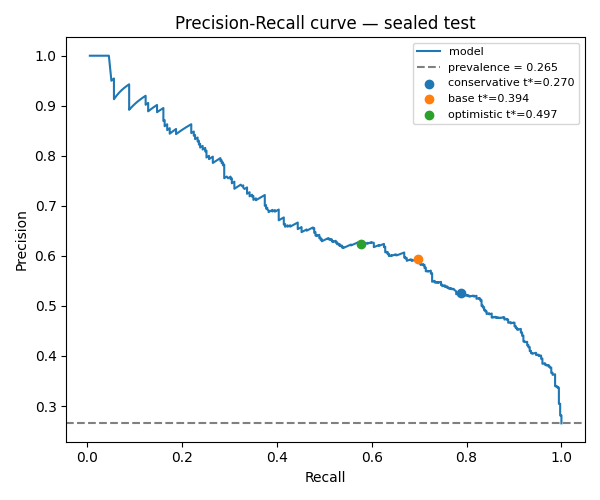
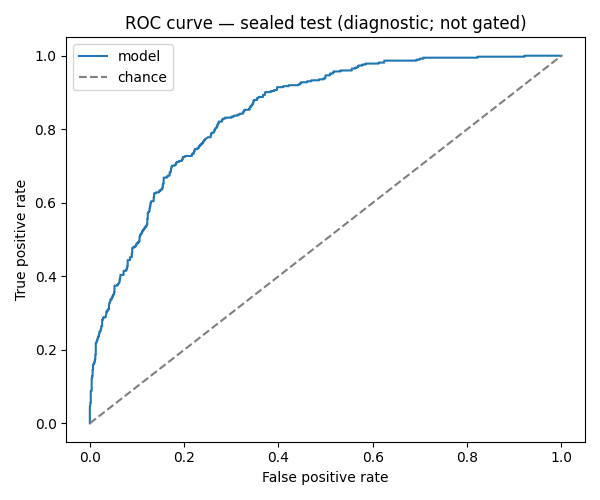

ROC-AUC (diagnostic, not gated): 0.8481  (95% CI [0.8276, 0.8675])


In [4]:
ranking = metrics["ranking"]

pr_curve_b64 = base64.b64encode((figures_dir / "pr_curve_test.png").read_bytes()).decode("ascii")
roc_curve_b64 = base64.b64encode((figures_dir / "roc_curve_test.png").read_bytes()).decode("ascii")
display(
    HTML(
        '<div style="display:flex; align-items:flex-start; gap:24px; flex-wrap:wrap;">'
        f'<div><img src="data:image/png;base64,{pr_curve_b64}" style="max-width:100%;"></div>'
        f'<div><img src="data:image/png;base64,{roc_curve_b64}" style="max-width:100%;"></div>'
        "</div>"
    )
)

print(
    f"ROC-AUC (diagnostic, not gated): {ranking['roc_auc']:.4f}  "
    f"(95% CI [{ranking['roc_auc_ci_lower']:.4f}, {ranking['roc_auc_ci_upper']:.4f}])"
)

**Why PR-AUC, not ROC-AUC, drives the decision.** Only ~27% of customers churn, so ROC-AUC can
look strong even while missing many real churners: false positives are always a *tiny fraction* of
the much larger non-churner group, which is why the ROC curve above bows so far above the diagonal
(**0.848**). ROC-AUC also treats every cutoff equally, inviting the common (and wrong) assumption
of a 0.5 default — this model's three shipped thresholds, **0.270, 0.394, 0.497**, all sit below
0.5, set by the cost/benefit rule `t* = c / (r × LTV)` (Section 4), not by a target recall.

PR-AUC doesn't share that blind spot: precision (of flagged customers, the share who actually
churn) falls as recall (of churners, the share the model catches) rises — from near 1.0 down to
the **0.265** random-guessing floor at recall = 1.0. The bullets above report the model's overall
score: PR-AUC **0.670** (95% CI [0.619, 0.714]). The three markers on the curve are the shipped
thresholds themselves, each trading some precision for recall as a side effect of the cost-optimal
rule rather than a chosen target — the real trade-off an outreach campaign lives with
("Classification performance" below breaks it down per threshold). ROC-AUC is reported only
because it's the metric most readers already know how to sanity-check — and exactly the one that
would have overstated this model's readiness had it driven the decision.

### Classification performance

The panel below shows the confusion matrix and **positive-class** precision/recall/F1 (point
values), support, and contact rate for each shipped threshold (`configs/policy/threshold.yaml`).
The table underneath adds the one thing the panel doesn't: the bootstrap CI on **recall** — the
metric the promotion gate's guardrail checks — followed by a fixed-recall profile for planning
alternative operating points.

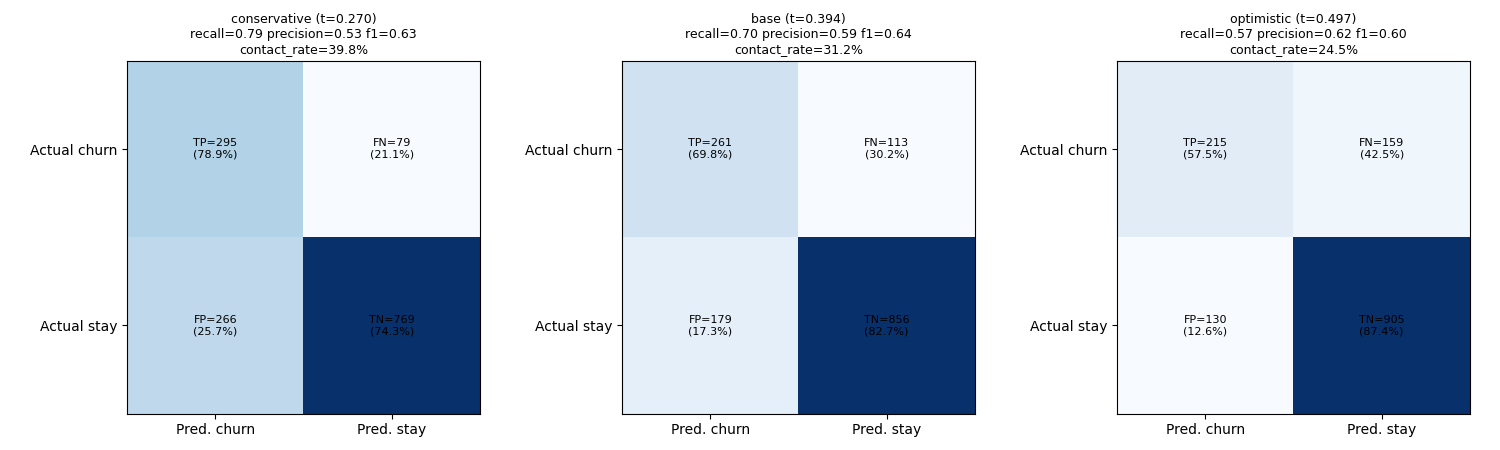

,recall_ci_lower,recall_ci_upper
scenario,,
conservative,0.747,0.829
base,0.651,0.743
optimistic,0.525,0.626


In [5]:
display(Image(filename=str(figures_dir / "classification_report_test.png")))

classification_df = pd.DataFrame(metrics["classification"]).set_index("scenario")
display(classification_df[["recall_ci_lower", "recall_ci_upper"]].style.format("{:.3f}"))

Recall falls and precision rises as the threshold moves from conservative to optimistic — the
same trade-off the PR curve showed in aggregate, now broken out per scenario. Conservative
(`t=0.270`) catches the most churners (recall 0.79, 95% CI [0.747, 0.829]) but at real cost: 266
false positives against 295 true positives, a 39.8% contact rate. Optimistic (`t=0.497`) is the
mirror image — precision 0.62, contact rate 24.5% — but its recall (0.57, 95% CI [0.525, 0.620])
would **not** clear the gate's 0.65 guardrail even at the top of its own CI, were it adopted as the
shipped threshold instead of base.

Base (`t=0.394`) is what's actually shipped, and its recall — 0.698, 95% CI [0.651, 0.743] — is the
number the promotion gate checked (Section 2): the whole interval clears the 0.65 bar, so the
guardrail passes on more than a lucky point estimate. In plain terms: of the 374 churners in the
sealed test set, base flags 261 for outreach — a shot at saving them — while missing 113 with no
intervention attempted; separately, 179 non-churners get contacted for nothing. Section 4
(Business impact) converts these counts into dollars — campaign cost and retained revenue. F1 is
fairly flat across all three scenarios (0.60–0.64), which is expected — it weights precision and
recall equally, while the shipped threshold is chosen to maximize expected value, not F1.

#### Fixed-recall profile — planning alternative operating points

This sweep isn't a separate analysis per scenario — there is only one probability vector for this
model on the sealed test set, and therefore one PR curve. The three shipped scenarios above are
themselves just three points already on that curve, picked by plugging different cost/retention/
LTV assumptions into `t* = c/(r×LTV)`. The rows below read three *other* points off that same
curve: what threshold and precision would be needed to guarantee 70%, 80%, or 90% recall,
regardless of cost economics.

In [6]:
fixed_recall_df = pd.DataFrame(metrics["fixed_recall_profile"]).set_index("recall_target")
display(fixed_recall_df.style.format("{:.2f}").format_index("{:.2f}", axis=0))

,precision,recall_achieved,f1,threshold
recall_target,,,,
0.70,0.59,0.70,0.64,0.39
0.80,0.52,0.80,0.63,0.26
0.90,0.47,0.90,0.61,0.15


The 0.70 row lands almost exactly on **base** (threshold 0.39, precision 0.59), confirming the
cost-optimal shipped threshold already sits close to a 70%-recall operating point. Pushing further
costs more precision than any shipped scenario risks: 80% recall needs precision 0.52, and 90%
recall — beyond what even **conservative** achieves (recall 0.79) — needs precision 0.47, roughly
a coin flip on every flagged customer. None of these rows are gated or shipped; they exist so a
reviewer can see what "more aggressive than conservative" would actually cost before asking for
it.

### Calibration detail

Sigmoid calibration was selected on **development OOF** probabilities, with its Brier Skill Score
reported there — whether that transfers to genuinely held-out data is answered here, once. Brier
alone isn't a full calibration report: it blends calibration with ranking quality (Murphy's
decomposition below makes that explicit), so the **calibration slope** — binning-free,
parameter-free, and immune to being "bought" by better ranking — is the guardrail the gate table
above actually reads. (The before/after comparison that justified choosing sigmoid calibration in
the first place lives on dev-OOF, in `reports/figures/reliability_diagram.png` — not repeated
here.)

In [7]:
calibration = metrics["calibration"]
print(f"Brier (candidate)        : {calibration['brier']:.4f}")
print(f"Brier (dummy-prior floor) : {calibration['dummy_prior_brier']:.4f}")
print(f"Brier Skill Score (BSS)  : {calibration['bss']:.4f}   (0 = no better than the floor, 1 = perfect)")
print(f"ECE                      : {calibration['ece']:.4f}   (reported diagnostic — binning-dependent, not gated)")

decomp = calibration["murphy_decomposition"]
print()
print("Murphy's decomposition — Brier = reliability - resolution + uncertainty:")
print(f"  reliability (calibration error) : {decomp['reliability']:.4f}")
print(f"  resolution  (discrimination)    : {decomp['resolution']:.4f}")
print(f"  uncertainty (outcome variance)  : {decomp['uncertainty']:.4f}")
print(f"  reconstructed Brier             : {decomp['brier_reconstructed']:.4f}  (directly-computed: {calibration['brier']:.4f})")

slope = calibration["calibration_slope"]
band_lower, band_upper = 0.80, 1.25
slope_vetoes = slope["slope_ci_upper"] < band_lower or slope["slope_ci_lower"] > band_upper
print()
print(f"Calibration slope        : {slope['slope']:.4f}  (95% CI [{slope['slope_ci_lower']:.4f}, {slope['slope_ci_upper']:.4f}])")
print(f"Guardrail band           : [{band_lower}, {band_upper}]")
print(f"Guardrail verdict        : {'VETO — CI entirely outside the band' if slope_vetoes else 'pass — CI overlaps the band'}")

Brier (candidate)        : 0.1363
Brier (dummy-prior floor) : 0.1950
Brier Skill Score (BSS)  : 0.3010   (0 = no better than the floor, 1 = perfect)
ECE                      : 0.0346   (reported diagnostic — binning-dependent, not gated)

Murphy's decomposition — Brier = reliability - resolution + uncertainty:
  reliability (calibration error) : 0.0020
  resolution  (discrimination)    : 0.0598
  uncertainty (outcome variance)  : 0.1950
  reconstructed Brier             : 0.1372  (directly-computed: 0.1363)

Calibration slope        : 0.9921  (95% CI [0.8909, 1.1000])
Guardrail band           : [0.8, 1.25]
Guardrail verdict        : pass — CI overlaps the band


Brier (0.136) beats the dummy-prior floor (0.195 — the score of always predicting the base churn
rate) by enough to give a BSS of 0.301: the model's probabilities carry real information, not just
point estimates that happen to average out. Murphy's decomposition shows why — **reliability**
(0.002, calibration error) is tiny, **resolution** (0.060, discrimination) is doing almost all the
work, and **uncertainty** (0.195, the outcome's own base-rate variance) is fixed by the data, not
the model; the reconstructed Brier (0.137) matches the directly-computed one (0.136) up to the
usual quantile-bin rounding. ECE (0.035) points the same direction as reliability but isn't gated,
for the reasons above. The **calibration slope** — 0.992, 95% CI [0.891, 1.100] — is the guardrail
that matters: it sits almost exactly at the 1.0 of perfect calibration, and its CI clears
[0.80, 1.25] with room on both sides, so the pass verdict isn't a borderline call.

Put together: BSS confirms the probabilities are informative, Murphy's decomposition shows that
informativeness isn't coming at the expense of reliability, and the calibration slope confirms the
posteriors are honest enough for `t* = c/(r×LTV)` to be the right threshold. As established in
Section 2, a guardrail can only cost a promotion, never grant one — here it simply confirms the
PR-AUC-driven admission stands.

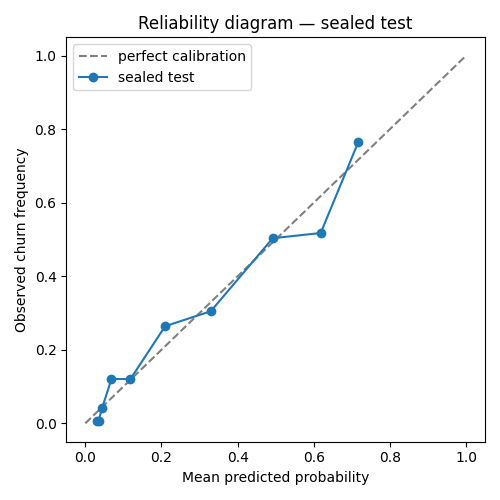

In [8]:
display(Image(filename=str(figures_dir / "reliability_diagram_test.png")))

The ten quantile bins (~141 test rows each) track the diagonal closely across the full score
range, consistent with the near-1.0 slope above. The wobble at the low end (predicted ~0.03–0.12,
observed swinging between 0.01 and 0.12 bin to bin) is binning noise from thin churner counts in
low-risk bins, not a systematic bias — it doesn't point one direction consistently. The largest
single gap on the chart sits just below the top: predicted 0.62 vs. observed 0.52 — the model is
mildly overconfident in that band, flagging more risk than the data bears out — before swinging
back the other way in the top bin (predicted 0.72 vs. observed 0.77), which is mildly
underconfident instead.

In plain terms: a few individual bins are a bit off — the model over-estimates risk around 0.62
and under-estimates it around 0.72 — but these errors point in different directions and roughly
cancel out rather than adding up. There's no consistent pattern of the model being too confident,
or not confident enough, across the board — which is what actually matters for trusting these
probabilities when deciding who to contact.

## 3. Ranking diagnostics — gains, lift, and the decile table

Threshold-free views of the same ranking PR-AUC summarises, read as a contact-budget question:
contacting only the highest-risk decile 1 (top 10%), decile 2 (top 20%), decile 5 (top 50%), or
all the way to decile 10 (100%), how much churn gets caught? The **cumulative gains curve** (left)
plots that capture rate against a **perfect ranker** (green, every churner contacted before any
non-churner — the ceiling no model can beat) and the diagonal a random contact list would achieve.
The **lift bars** (right) show how much more churn-dense each decile is than the population
average. The table below gives exact values for both charts (`lift`, `cumulative_capture_rate`,
`perfect_capture_rate`), plus raw counts, how closely each decile's average predicted risk
(`mean_predicted`) matches its actual `churn_rate`, and `headroom` — the gap between the model and
the perfect-ranker ceiling at that same contact budget. Deciles 9 and 10 carry only 1 churner each
despite the same ~141-row size as every other decile — their `churn_rate` is barely more than a
coin flip's worth of evidence, not a precise measurement.

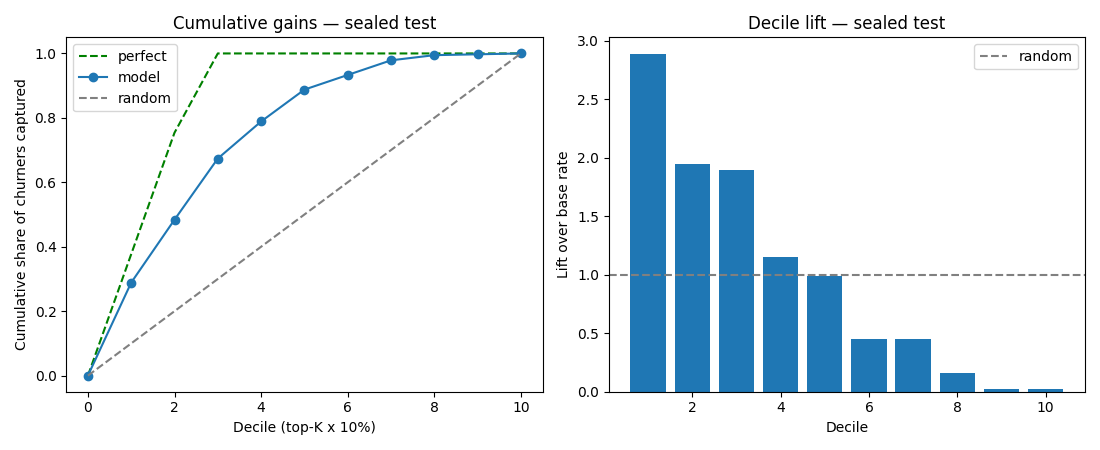

,count,n_churners,churn_rate,mean_predicted,lift,cumulative_capture_rate,perfect_capture_rate,headroom
decile,,,,,,,,
1,141,108,0.766,0.717,2.89,28.9%,37.7%,8.8%
2,141,73,0.518,0.618,1.95,48.4%,75.4%,27.0%
3,141,71,0.504,0.492,1.90,67.4%,100.0%,32.6%
4,141,43,0.305,0.330,1.15,78.9%,100.0%,21.1%
5,141,37,0.262,0.209,0.99,88.8%,100.0%,11.2%
6,141,17,0.121,0.118,0.45,93.3%,100.0%,6.7%
7,141,17,0.121,0.068,0.45,97.9%,100.0%,2.1%
8,141,6,0.043,0.044,0.16,99.5%,100.0%,0.5%
9,141,1,0.007,0.035,0.03,99.7%,100.0%,0.3%


In [9]:
display(Image(filename=str(figures_dir / "gains_lift_test.png")))

decile_df = pd.DataFrame(metrics["decile_lift"]).set_index("decile")
decile_df.index = decile_df.index.astype(int)
display(
    decile_df[
        [
            "count",
            "n_churners",
            "churn_rate",
            "mean_predicted",
            "lift",
            "cumulative_capture_rate",
            "perfect_capture_rate",
            "headroom",
        ]
    ].style.format(
        {
            "count": "{:.0f}",
            "n_churners": "{:.0f}",
            "churn_rate": "{:.3f}",
            "mean_predicted": "{:.3f}",
            "lift": "{:.2f}",
            "cumulative_capture_rate": "{:.1%}",
            "perfect_capture_rate": "{:.1%}",
            "headroom": "{:.1%}",
        }
    )
)

Decile 1 alone — the riskiest 10% of customers — captures **28.9%** of all churners at **2.89x**
the base churn rate; by decile 3 (top 30%), the model has already found **67.4%** of them, close
to where the shipped base scenario actually lands (31.2% contact rate, Section 4). Lift drops
below 1.0 at decile 5: from there on, each additional 10% of customers contacted is *below*-average
risk, and the bottom half of the ranking (deciles 6–10) adds only 42 more churners combined out of
374 — the gains curve is essentially flat by then, which is what a model that ranks risk well
should look like.

A **perfect ranker** would already have every churner in hand by decile 3 (base churn rate ≈27%,
so the top 30% of customers is enough room to fit all of them) — that's the ceiling
`perfect_capture_rate` reaches 100% and stays there. At that same decile 3, the three reference
points line up as **random ~30%, model 67.4%, perfect 100%**: the model captures more than double
what random targeting would, while still leaving `headroom` of **32.6pp** against the ceiling
(model 67.4% vs. a possible 100%). That headroom shrinks steadily after decile 3, down to under
1pp by decile 8: most of the achievable separation is exploited by mid-ranking, and what's left
is concentrated in the top 30%, not spread evenly across the curve.

`mean_predicted` tracks `churn_rate` closely decile-by-decile — the same per-decile version of
the calibration slope from Section 2 — with the same wobble already flagged in the reliability
diagram: decile 2 is mildly overconfident (0.618 predicted vs. 0.518 actual) and decile 1 mildly
underconfident (0.717 vs. 0.766), errors pointing in opposite directions rather than a one-way
bias. Put together: the model comfortably beats random targeting, gets most of the way to what a
perfect ranker could achieve within the same budget, and that concentration is trustworthy rather
than an artifact of miscalibration.

## 4. Business impact — expected value across three cost scenarios

This section converts Sections 2–3's ranking/calibration verdict into dollars: is deploying this
model worth it? Per scenario, it reports **expected value (EV)** plus its two components — gross
campaign cost ((true positives + false positives) × cost per contact) and gross retained revenue
(true positives × retention rate × customer lifetime value) — against the two baselines the model
must beat to justify deploying it at all: *treat-all* (contact every customer in the sealed test
set, no model needed) and *treat-none* (contact nobody, EV = $0 by construction), both scaled to
the same 1,409-row sample every other number here comes from, not the full company customer base.

**The scenario bracket isn't a confidence interval**: `retention_rate` and `outreach_cost` are
benchmark guesses, not measurements, so the bracket reflects that parameter uncertainty, while
each scenario's own bootstrap CI reflects sampling uncertainty from the sealed test set — the two
are checked below to confirm neither is masking the other. The sensitivity tornado and break-even
heatmap that follow show which input the number is most fragile to, and what retention rate a real
campaign needs to hit to break even.

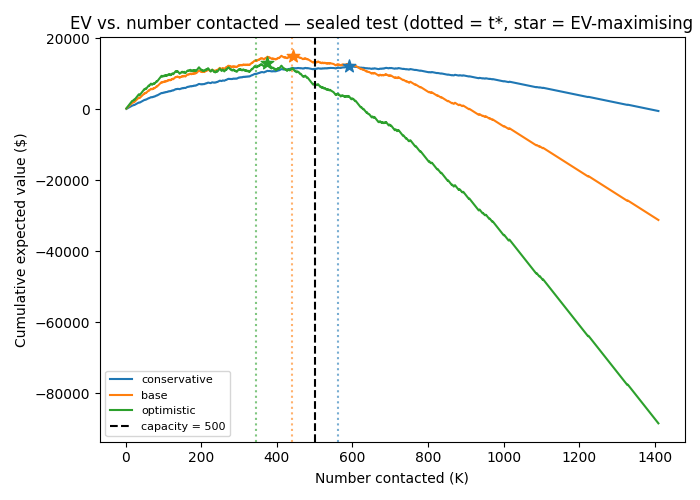

,threshold (t*),contact_rate,n_contacted,campaign_cost ($),retained_revenue ($),EV ($),EV CI lower,EV CI upper,EV treat-all ($),EV treat-none ($),break_even_retention_rate
scenario,,,,,,,,,,,
conservative,0.2696,39.8%,561,"12,343","24,076","11,732","9,496","13,719",-479,0,0.103
base,0.3941,31.2%,440,"29,814","44,875","15,061","11,215","18,604","-31,170",0,0.199
optimistic,0.4968,24.5%,345,"46,499","58,329","11,830","6,794","16,578","-88,440",0,0.319



Scenario bracket (parameter uncertainty): $11,732 — $15,061  (spread $3,329)
Widest within-scenario bootstrap CI width (sampling uncertainty): $9,784
parameter_spread_dominates_sampling: False


In [10]:
display(Image(filename=str(figures_dir / "ev_by_budget.png")))

business = metrics["business_impact"]
scenario_rows = []
for name, row in business["scenarios"].items():
    scenario_rows.append(
        {
            "scenario": name,
            "threshold (t*)": row["threshold"],
            "contact_rate": row["contact_rate"],
            "n_contacted": row["n_contacted"],
            "campaign_cost ($)": row["campaign_cost"],
            "retained_revenue ($)": row["retained_revenue"],
            "EV ($)": row["ev"],
            "EV CI lower": row["ev_ci_lower"],
            "EV CI upper": row["ev_ci_upper"],
            "EV treat-all ($)": row["ev_treat_all"],
            "EV treat-none ($)": row["ev_treat_none"],
            "break_even_retention_rate": row["break_even_retention_rate"],
        }
    )
scenario_df = pd.DataFrame(scenario_rows).set_index("scenario")
display(
    scenario_df.style.format(
        {
            "threshold (t*)": "{:.4f}",
            "contact_rate": "{:.1%}",
            "campaign_cost ($)": "{:,.0f}",
            "retained_revenue ($)": "{:,.0f}",
            "EV ($)": "{:,.0f}",
            "EV CI lower": "{:,.0f}",
            "EV CI upper": "{:,.0f}",
            "EV treat-all ($)": "{:,.0f}",
            "EV treat-none ($)": "{:,.0f}",
            "break_even_retention_rate": "{:.3f}",
        }
    )
)

print(
    f"\nScenario bracket (parameter uncertainty): "
    f"${business['ev_bracket_min']:,.0f} — ${business['ev_bracket_max']:,.0f}  "
    f"(spread ${business['ev_spread']:,.0f})"
)
print(f"Widest within-scenario bootstrap CI width (sampling uncertainty): ${business['widest_within_scenario_ci_width']:,.0f}")
print(f"parameter_spread_dominates_sampling: {business['parameter_spread_dominates_sampling']}")

Each curve is cumulative EV as the top-K riskiest customers are contacted: an inverted U that
rises, peaks near each scenario's shipped threshold (dotted line, closely matched by the star
marking the empirical EV-maximizing K), then falls as further customers cost more than they
return. The fall is steepest for optimistic ($135/contact, ending near **-$88k** at K=1,409) and
gentlest for conservative ($22/contact, ending near **$0**) — base sits in between ($68/contact)
and ends near **-$31k**, exactly `EV treat-all`. The black dashed line at K=500 is
`contact_capacity`, a fixed operational limit unrelated to cost economics: conservative's shipped
K (561) already exceeds it, so the team couldn't actually run conservative at its cost-optimal
point, while base (440) and optimistic (345) both fit comfortably underneath.

All three scenarios clear both baselines — `EV treat-all` is negative throughout, `EV treat-none`
is $0 by construction. Cost and revenue both scale up together across scenarios (cost
$12k→$30k→$46k, revenue $24k→$45k→$58k), yet net EV stays in a narrow **$11.7k–$15.1k** band;
`break_even_retention_rate` scales the same way (10.3%→19.9%→31.9%), so despite its name,
**optimistic actually needs the highest real-world retention success to pay off**. That narrow EV
band is smaller than sampling noise: the scenario bracket (spread **$3,329**) is narrower than the
widest single scenario's own bootstrap CI (**$9,784**, from optimistic) —
`parameter_spread_dominates_sampling` reads **False**, meaning the ranking between scenarios isn't
a confident signal even though all three clear both baselines.

### Sensitivity — where does this number come from, and how fragile is it?

Every EV figure above rests on three assumptions this dataset can't measure directly —
`retention_rate`, `cost` (per customer contacted — outreach labor plus the expected
retention-offer discount, bundled), and `ltv` — so this subsection checks how much the answer
moves if one of them is off. The **tornado diagram** (left) perturbs each ±20% around its shipped
value, one at a time, and ranks them by how far EV swings — `retention_rate` and `ltv` move it
equally, `cost` moves it less, and the explanation below unpacks why. The **break-even heatmap**
(right) turns that into the question a stakeholder actually asks: *at this cost per customer
contacted, how high does retention need to be for the campaign to stay profitable?* — the EV = 0
line traced across the retention-rate × cost grid.


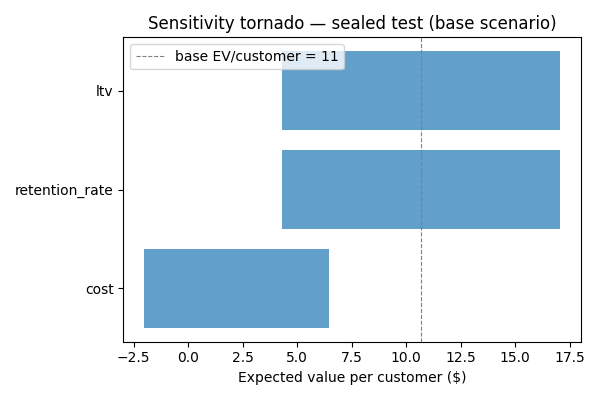
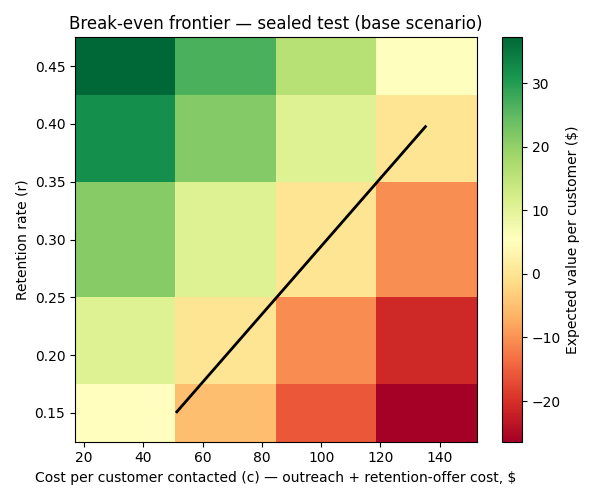

,ev_base,ev_low,ev_high,spread
param,,,,
ltv (customer lifetime value),10.69,4.32,17.06,12.74
retention_rate,10.69,4.32,17.06,12.74
cost,10.69,14.92,6.46,8.46


In [11]:
tornado_b64 = base64.b64encode((figures_dir / "sensitivity_tornado.png").read_bytes()).decode("ascii")
breakeven_b64 = base64.b64encode((figures_dir / "breakeven_heatmap.png").read_bytes()).decode("ascii")
display(
    HTML(
        '<div style="display:flex; align-items:flex-start; gap:24px; flex-wrap:wrap;">'
        f'<div><img src="data:image/png;base64,{tornado_b64}" style="max-width:100%;"></div>'
        f'<div><img src="data:image/png;base64,{breakeven_b64}" style="max-width:100%;"></div>'
        "</div>"
    )
)

tornado_df = pd.DataFrame(economics["sensitivity"]["tornado"]).set_index("param")
tornado_df = tornado_df.sort_values("spread", ascending=False)
tornado_df = tornado_df.rename(index={"ltv": "ltv (customer lifetime value)"})
display(tornado_df.style.format("{:.2f}"))

`retention_rate` and `ltv` tie as the two biggest swing factors — a ±20% miss on either moves
per-customer EV the same **$12.74** (from **$4.32** to **$17.06**, around the **$10.69** base).
That's because retained revenue is `retention_rate` multiplied by `ltv`: a 20% error in either one
shifts the revenue estimate — and so EV — by the same amount, which is why the two carry equal
weight in the chart. `cost` matters less: the same ±20% perturbation only swings EV by **$8.46**
($6.46–$14.92) — even a 20% cost overrun leaves EV solidly positive. That's the concrete case for
treating `retention_rate` as the assumption worth stress-testing hardest: it's the benchmark guess
this deployment decision is most exposed to.

The break-even heatmap answers a simpler question directly: at a given cost per customer
contacted, how much of the churners contacted need to actually be retained for the campaign to pay
for itself? The black line marks that exact break-even point across every cost level; colour then
shades from red (a loss) through pale yellow (near break-even) to green (a solid profit) on either
side of it. At the base scenario's actual cost (**$67.76** per customer contacted — outreach labor
plus the expected retention-offer discount, not just the $20 labor component alone), that line
crosses at **19.9%** retention needed — the same number already reported in Section 4. The
campaign assumes **30%** retention, so there's real room for error: retention would have to come
in about a third lower than expected before the campaign stopped paying off.

### Bottom line for stakeholders

**Yes, deploy — at the base scenario.** All three cost scenarios turn a profit and beat both
baselines, and base's operating point is the one both financially comfortable (a real margin
between its break-even retention rate and what's assumed) and operationally executable (fits under
`contact_capacity`, unlike conservative). Its higher point-estimate EV isn't a proven edge over the
other two — `parameter_spread_dominates_sampling` reads **False** above — so the case for base
rests on that operational fit, not a statistically confident EV advantage. The one number worth
tracking after a real campaign runs: whether retention actually clears its break-even rate.

## 5. Disaggregated sealed-test metrics — robustness & fairness

The same sealed-test probability vector, sliced two ways: **robustness** axes (`contract_type`,
`tenure_cohort`, `internetservice` — does the model hold up across operationally meaningful
segments?) and **protected/quasi-protected** axes (`gender`, `seniorcitizen`, `has_partner`,
`dependents` — does it treat sensitive groups consistently?). Four views of those same slices
follow: ranking (PR-AUC), decision rates at the shipped threshold plus the two fairness-gap
metrics, what those gaps cost in dollars, and calibration.

This is reported evidence for the model card, not a decision surface — the same three checks
(V1/V2/V2b) are computed on dev-OOF in **[§4 Pre-seal dev-OOF screen & diagnostics](04-calibration-and-threshold.ipynb)**,
which carries roughly 4x the churners and can actually distinguish a real segment collapse from noise. Neither surface gates promotion (only the direction sanity check does — Section 8);
expect thin support and wide CIs on the low-churn tiers here, that's the honest finding, not a bug.

### Ranking by slice — PR-AUC

In [12]:
test_ranking_df = pd.DataFrame(metrics["sliced"]["test"]["ranking"]).set_index(["axis", "value"])
display(
    test_ranking_df[["n", "pr_auc_obs", "pr_auc_ci_lower", "pr_auc_ci_upper", "churn_rate_floor"]].style.format(
        {"pr_auc_obs": "{:.3f}", "pr_auc_ci_lower": "{:.3f}", "pr_auc_ci_upper": "{:.3f}", "churn_rate_floor": "{:.3f}"}
    )
)

Ranking quality tracks how many churners a slice actually contains and how distinguishable they
are. Among the robustness axes: month-to-month contracts (PR-AUC 0.704, 95% CI [0.655, 0.752],
329 churners — 42.2% of 780) and 0-12-month tenure (0.782) rank confidently, fiber-optic customers
do best among internet types (0.741, 43.1% churn rate), while two-year contracts (0.157, CI
[0.060, 0.382], 2.7% churn rate) and 65+-month tenure (0.371, CI [0.163, 0.634]) carry wide
intervals — a handful of churners to rank, not worse ranking, echoing the thin-support caveat
above. In practice this is the right place for the model to be strong: month-to-month, new-tenure
customers are both where most churn happens and where the outreach budget goes, while the noisier
long-contract, long-tenure segments barely churn at all, so the uncertainty there costs little.

Among the protected axes, `gender` is the cleanest comparison (female 0.678 vs male 0.667, nearly
identical). The other three all show real gaps, but not all the same direction: `seniorcitizen`
customers — a minority slice by count (234 of 1,409) but with a 40.6% churn rate — actually rank
*better* than non-seniors (0.758 vs 0.639), while `dependents` shows the opposite and widest split
(no dependents 0.704 vs has dependents 0.419, non-overlapping CIs), and `has_partner` a smaller
version of the same pattern (0.714 vs 0.593). For a stakeholder, that means the campaign is more
reliable at catching at-risk seniors than at-risk customers with dependents or partners — worth
watching as a monitoring metric.

### Decision rates & fairness gaps by slice

In [13]:
test_decision_df = pd.DataFrame(metrics["sliced"]["test"]["decision_rates"]).set_index(["axis", "value"])
display(
    test_decision_df[["n", "selection_rate", "fnr", "fpr", "precision"]]
    .rename(
        columns={
            "fnr": "false_negative_rate (fnr)",
            "fpr": "false_positive_rate (fpr)",
        }
    )
    .style.format(
        {
            "selection_rate": "{:.1%}",
            "false_negative_rate (fnr)": "{:.3f}",
            "false_positive_rate (fpr)": "{:.3f}",
            "precision": "{:.3f}",
        }
    )
)

print("\nEqual-opportunity difference (max FNR gap) by axis:")
print(pd.Series(metrics["sliced"]["test"]["equal_opportunity_difference_by_axis"]).round(3))
print(f"\nOverall equal_opportunity_diff (max across axes): {metrics['sliced']['test']['equal_opportunity_diff']:.3f}")

print("\nDemographic-parity difference (max selection-rate gap) by axis:")
print(pd.Series(metrics["sliced"]["test"]["demographic_parity_difference_by_axis"]).round(3))
print(f"\nOverall demographic_parity_diff (max across axes): {metrics['sliced']['test']['demographic_parity_diff']:.3f}")


Equal-opportunity difference (max FNR gap) by axis:
gender           0.038
seniorcitizen    0.123
has_partner      0.194
dependents       0.351
dtype: float64

Overall equal_opportunity_diff (max across axes): 0.351

Demographic-parity difference (max selection-rate gap) by axis:
gender           0.030
seniorcitizen    0.230
has_partner      0.227
dependents       0.279
dtype: float64

Overall demographic_parity_diff (max across axes): 0.279


At the shipped threshold, contract length and tenure dominate who gets contacted. Two error
rates matter: **false-negative rate (FNR)**, the share of actual churners missed, and
**false-positive rate (FPR)**, the share of actual non-churners contacted anyway. Month-to-month
customers make up all 440 people flagged for outreach (selection rate 56.4%, FNR 20.7%, FPR
39.7%), while nobody on a one- or two-year contract clears the threshold — both sit at FNR 100%,
because the model correctly assigns them low risk, not a threshold quirk. `tenure_cohort` and
`internetservice` repeat the pattern (65+ months: 0.5% selection, FNR 92.3%; no internet: 1.3%,
FNR 82.6%) — their 100% precision comes from contacting only 1 and 4 people, not a real signal.
For stakeholders: a deliberate, cost-justified blind spot — the campaign concentrates where churn
and budget both are, but an unexpected churner outside that footprint will almost certainly go
uncontacted.

Among the protected axes, two fairness questions apply: **equal opportunity** — do actual churners
in every group have an equal chance of being flagged (a gap in FNR)? — and **demographic parity**
— does every group get a similar share of outreach regardless of who churns (a gap in selection
rate)? `gender`'s gaps stay small (3.8pp EO, 3.0pp DP); the other three don't. `dependents` is
largest on both — missed 60.4% of the time vs. 25.2% without (35.1pp EO), contacted at 11.2% vs.
39.1% (27.9pp DP) — which is why it sets the overall `equal_opportunity_diff`/`demographic_parity_diff`
printed above (the max across axes, tracked as its own metric since a future retrain could shift
which axis drives it). `has_partner` (19.4pp, 22.7pp) and `seniorcitizen` (12.3pp, 23.0pp) show
smaller versions of the same pattern. For stakeholders: the campaign is not equally effective at
reaching or protecting these groups today — the next subsection puts a dollar figure on exactly
what that gap costs.

### Business impact by slice

In [14]:
test_business_df = pd.DataFrame(metrics["sliced"]["test"]["business_impact"]).set_index(
    ["axis", "value"]
)
display(
    test_business_df[
        ["n", "n_churners", "campaign_cost", "retained_revenue", "missed_revenue", "ev"]
    ].style.format(
        {
            "campaign_cost": "{:,.0f}",
            "retained_revenue": "{:,.0f}",
            "missed_revenue": "{:,.0f}",
            "ev": "{:,.0f}",
        }
    )
)

Each row reuses Section 4's per-customer formulas (`campaign_cost`, `retained_revenue`, `ev`),
computed on that segment's rows alone at the same base-scenario threshold. `missed_revenue` is
new: that segment's false negatives (uncontacted churners) × `retention_rate` × `ltv` — what would
have been retained had they been flagged.

`dependents` shows the starkest split: without dependents nets **$14,499** EV (retained $41,265
vs. $26,765 cost); with dependents nets just **$561** — 26x smaller — and its `missed_revenue`
(**$5,502**) actually exceeds what's retained ($3,611). `has_partner` shows a smaller version of
the same asymmetry ($10,449 vs. $4,612 EV). `seniorcitizen` and `gender` are more balanced: seniors
miss 21% of their own revenue-at-risk (`missed_revenue` ÷ (`missed_revenue` + `retained_revenue`))
vs. 33% for non-seniors, and male customers miss 32% vs. 28% for female — both consistent with the
smaller FNR gaps above.

Is this a model problem? Largely no — `dependents`=Yes customers churn far less often to begin
with (13.3% vs. 31.8%), so fewer cross the one global threshold, and the group's calibration slope
(0.860) still sits inside the guardrail band. The choice here is a policy one, not a modelling
one: keep the single EV-maximizing threshold and accept this as the cost of uneven risk, or
deliberately subsidize outreach to lower-risk groups at some cost to aggregate EV — a trade-off
for the business to decide and revisit each retrain cycle, not something the threshold should
settle silently.

### Calibration by slice

In [15]:
test_calibration_df = pd.DataFrame(metrics["sliced"]["test"]["calibration"]).set_index(["axis", "value"])
display(
    test_calibration_df[["n", "slope", "slope_ci_lower", "slope_ci_upper", "ece"]].style.format(
        {"slope": "{:.3f}", "slope_ci_lower": "{:.3f}", "slope_ci_upper": "{:.3f}", "ece": "{:.3f}"}
    )
)

Every slice's calibration-slope CI overlaps the [0.80, 1.25] guardrail band except one:
two-year contracts, at 2.294 (CI [1.267, 3.890]) — nominally "underconfident" (actual outcomes
vary more sharply than the predicted probabilities suggest), but from only ~9 churners in 334
rows, the same thin-support caveat as the ranking slice above rather than real miscalibration. The
next-highest slopes point the same direction but still clear the band: 65+-month tenure (1.494)
and no-internet customers (1.519) — both long-tenure, rarely-churning segments drawn from the same
population as two-year contracts, so the pattern is consistent rather than an isolated flag. What
this means in practice: a predicted risk score carries the same real-world meaning regardless of
customer segment everywhere the campaign actually acts — two-year contracts already sit at a 0%
selection rate, so even a genuine miscalibration there would never misdirect an outreach decision.
ECE stays in a narrow 0.027–0.085 range across every axis, including the protected ones (gender:
0.052 female vs. 0.041 male) — no segment stands out as an outlier on this diagnostic.

## 6. Error analysis — where, how wrong, and what did it cost?

Sections 2–5 answered *how well* the model performs. This section answers *why* it gets specific customers wrong, and what that costs. Only the first piece below — the automated cohort scan — runs on dev-OOF (it needs the extra sample size, and scanning every feature for the worst cohort is exactly the kind of open-ended search that should stay off the sealed set; see that subsection's intro for why). Everything after it — the near-miss vs. confident-failure breakdown, the value-weighted cost, and the SHAP-based explainability — runs on the actual sealed test set: the model's real, held-out performance. That explainability work closes with a **direction sanity check**: does any top-ranked SHAP feature's learned effect direction contradict the established EDA relationship? If it does, that means the model learned the *wrong* relationship between that feature and churn — e.g. treating a feature EDA showed *reduces* churn risk as if it *increases* it — a coincidental quirk of this dataset rather than a real pattern, and one no aggregate metric like PR-AUC would ever reveal. It is the one check in this whole section that can veto the model.

### Error concentration — automated cohort scan

This scans every feature — categorical as-is, numeric quantile-binned — for the highest-error-rate cohorts, in two passes: false negatives, then false positives. It runs on dev-OOF rather than the sealed test set for two reasons: the extra rows are needed to support a scan across many small cohorts, and an open-ended search like this must stay **confirmatory, never generative** — a finding here may inform the review below, but must never send a reviewer back to engineer a feature and contaminate the seal.

#### False negatives — missed churners

Ranks cohorts by false-negative rate: among a cohort's actual churners, what share did the model miss? This is the primary business risk the project's cost structure is built around — a missed churner is one the retention campaign never had a chance to save.

In [17]:
fnr_cohorts_df = pd.DataFrame(error_analysis["error_concentration"]["dev_oof_top_fnr_cohorts"]).drop(columns="metric").rename(columns={"n_target": "n_churners"})
display(fnr_cohorts_df.style.format({"rate": "{:.1%}"}))

,feature,value,type,n,n_churners,rate
0,contract_type,Two year,categorical,1361,39,100.0%
1,contract_type,One year,categorical,1178,130,99.2%
2,tenure,"(61.0, 72.0]",numeric_bin,1066,69,92.8%
3,internetservice,No,categorical,1207,90,90.0%
4,onlinesecurity,No internet service,categorical,1207,90,90.0%
5,onlinebackup,No internet service,categorical,1207,90,90.0%
6,deviceprotection,No internet service,categorical,1207,90,90.0%
7,techsupport,No internet service,categorical,1207,90,90.0%
8,streamingtv,No internet service,categorical,1207,90,90.0%
9,streamingmovies,No internet service,categorical,1207,90,90.0%


Rows 3–9 are the same 1,207 customers counted seven times — `internetservice=No` and its six downstream add-on features are trivially "No internet service" together. Two distinct patterns sit in this table, not one. The first is long tenure and a long-term contract (92.8% FNR at 61–72 months, 72.1% at 39–61 months; 99.2% one-year, 100% two-year) — the model has learned "long tenure + long contract = safe" as a near-absolute prior. The second is low monthly charges (75% FNR in the cheapest bin) and no internet service (90% FNR) — a separate, moderate-tenure, mixed-contract cohort that simply never triggers the high-charges signal the model otherwise leans on heavily. `techsupport=Yes` (62.8% FNR) adds a third axis nobody would have thought to check ahead of time. A likely reason both patterns happen: nothing in this dataset distinguishes a quietly-leaving loyal customer from a genuinely loyal one, so the model leans entirely on whichever proxy it has — contract commitment for the first pattern, the absence of a high-charges signal for the second.

This isn't a tiny edge case: 169 real churners (130 one-year plus 39 two-year contract customers) are missed by the long-tenure/long-contract pattern alone. And contrary to what might be assumed, these aren't low-value customers — one-year and two-year contract churners average $85–87/month, notably more than the $73/month average for the month-to-month churners the model does catch. So this blind spot is missing higher-than-average-value customers, and the financial exposure is worse than the miss rate alone suggests, not softened by it.

#### False positives — false alarms

Ranks cohorts by false-positive rate: among a cohort's actual non-churners, what share did the model flag anyway? Each false positive wastes a contact on someone who was never leaving — cheaper than missing a real churner, but not free — so a high false-positive rate means a cohort where the campaign burns a large share of its budget on customers who didn't need it.

In [18]:
fpr_cohorts_df = pd.DataFrame(error_analysis["error_concentration"]["dev_oof_top_fpr_cohorts"]).drop(columns="metric").rename(columns={"n_target": "n_non_churners"})
display(fpr_cohorts_df.style.format({"rate": "{:.1%}"}))

,feature,value,type,n,n_non_churners,rate
0,tenure,"(-0.001, 6.0]",numeric_bin,1191,563,51.2%
1,charge_per_service,"(20.493, 36.125]",numeric_bin,1127,566,50.9%
2,paymentmethod,Electronic check,categorical,1877,1022,42.4%
3,contract_type,Month-to-month,categorical,3095,1769,40.1%
4,totalcharges,"(18.799, 265.78]",numeric_bin,1125,605,38.2%
5,techsupport,No,categorical,2786,1623,36.9%
6,internetservice,Fiber optic,categorical,2493,1456,36.1%
7,onlinesecurity,No,categorical,2816,1649,35.9%
8,seniorcitizen,1,categorical,908,527,34.5%
9,deviceprotection,No,categorical,2498,1525,33.4%


Two distinct patterns emerge here, not one — confirmed against the underlying data rather than assumed from the row list. The first is new sign-ups on flexible terms: short-tenure customers (51.2% FPR at 0–6 months, 27.1% at 6–20 months) are overwhelmingly month-to-month (40.1% FPR) and paying by electronic check (42.4% FPR) — 95% of the 0–6 month cohort is on a month-to-month contract — so the newer the customer, the more false alarms. The second is moderate-tenure customers (~26–34 months) paying more per month who simply stay anyway: high monthly charges (`charge_per_service`/`monthlycharges` top bins, 30–51% FPR), fiber optic service (36.1%), and no add-ons (`techsupport`, `onlinesecurity`, `deviceprotection`, `onlinebackup`, `streamingmovies` all "No": 27–37% each) all trip the model's dominant "high charges = risk" signal on premium-service customers who happen to stay.

A likely reason this happens: this feature set has no loyalty or satisfaction signal, so there is no clean boundary between a genuinely at-risk customer and one who simply looks like one on paper — whether that's a brand-new sign-up or a long-standing premium subscriber. A false positive spends the contact cost with no retained-revenue benefit, and several of these cohorts are large (`contract_type=Month-to-month` alone is 3,095 customers) — cheaper than a miss individually, but meaningful wasted spend at real volume.

### Error confidence — near-miss vs. confident failure

Not every error is wrong in the same way — how close the model's score sat to the decision cut-off
`t*` matters as much as whether the prediction was right or wrong. An error just on the wrong side of
`t*` is a **threshold artifact**: the model's estimate was already close to right, and only the
cutoff's exact placement flipped the outcome — a customer scored 0.36 against a cutoff of 0.39 would
have been called correctly had the line sat just slightly lower. An error far from `t*` — a churner
scored near 0, or a loyal customer scored near 1 — is a **confident failure**: the model was sure,
and wrong anyway. The near-miss band below marks that 'just on the wrong side' zone; its width comes
from `threshold.py`'s own bootstrap uncertainty on `t*`, not a fixed number. Concretely, a false
negative or false positive is flagged as a near-miss if its score falls within the band of `t*`
(`|score - t*| <= band`); everything else is a confident failure.

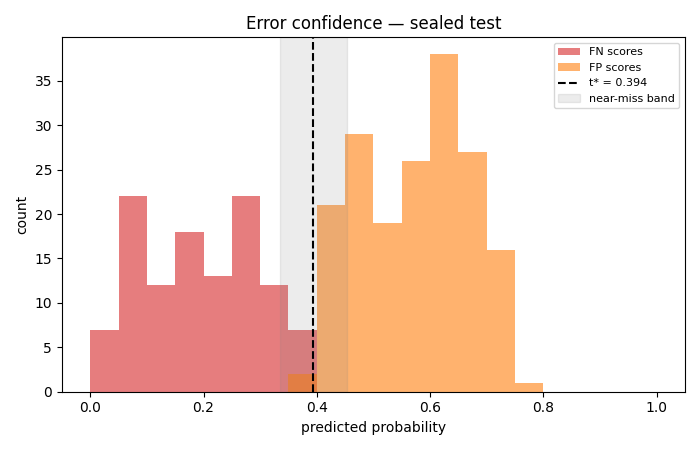

Threshold (t*)      : 0.3941
Near-miss band       : +/- 0.0586
False negatives (n)  : 113   near-miss share: 9.7%
False positives (n)  : 179   near-miss share: 12.8%


In [19]:
display(Image(filename=str(figures_dir / "error_confidence.png")))

confidence = error_analysis["error_confidence"]
print(f"Threshold (t*)      : {confidence['threshold']:.4f}")
print(f"Near-miss band       : +/- {confidence['near_miss_band']:.4f}")
print(f"False negatives (n)  : {confidence['n_fn']}   near-miss share: {confidence['fn_near_miss_share']:.1%}")
print(f"False positives (n)  : {confidence['n_fp']}   near-miss share: {confidence['fp_near_miss_share']:.1%}")

At `t* = 0.3941 ± 0.0586` (band [0.336, 0.453]), the near-miss band captures only a thin slice of either error type: 9.7% of the 113 false negatives (11 customers) and 12.8% of the 179 false positives (23 customers). The other 90%+ of both are confident failures, not threshold artifacts. But the two error types fail differently. Missed churners (false negatives) are spread thinly across the entire range below the band — plenty of them sit near 0, customers the model was never close to flagging as a risk. False alarms (false positives), by contrast, bunch up around 0.55–0.65 — comfortably above `t*`, not just barely over it.

This bounds what re-deriving `t*` could ever fix: moving the cut would flip only the handful of near-miss cases, leaving the bulk of both error types untouched — a threshold change cannot repair a ranking mistake. The confidently-missed churners are the same population behind the annual-contract / long-tenure blind spot above: nothing in the feature set raises their score in the first place. The confidently-flagged non-churners are the two false-alarm clusters above — new sign-ups and premium stayers whose profile looks identical to a real churner's. Both are feature problems, not threshold problems, which is exactly what the small near-miss shares say.

### Value-weighted errors — are we missing the expensive churners?

Every error rate elsewhere in this notebook treats one false negative the same as any other — a miss
is a miss, regardless of who it was. But the dollar cost of missing a churner is not uniform: it's the
revenue retained by catching that specific customer, and that revenue varies a lot across the customer
base — the cheapest and priciest customers here pay very different monthly bills. This section checks
whether the model's errors concentrate among the customers who are actually worth the most, using
`MonthlyCharges` — the direct revenue proxy already used elsewhere in this project — as the value
measure. Customers are split into deciles by `MonthlyCharges` (decile 1 = cheapest tenth, decile 10 =
most expensive), and false-negative/false-positive rates are computed within each.

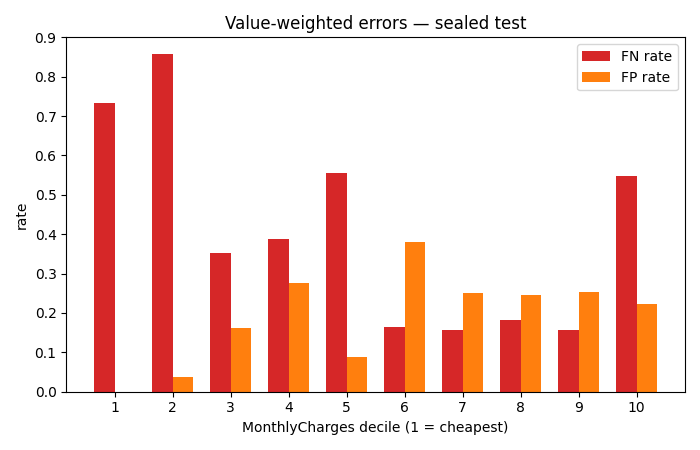

,range,n,mean_value,n_pos,n_neg,fn_rate,fp_rate
decile,,,,,,,
1,"[18.25, 20.10)",144,19.68,15,129,73.3%,0.0%
2,"[20.10, 24.95)",143,21.83,7,136,85.7%,3.7%
3,"[24.95, 44.82)",136,32.33,37,99,35.1%,16.2%
4,"[44.82, 55.41)",141,50.47,36,105,38.9%,27.6%
5,"[55.41, 69.75)",141,62.73,18,123,55.6%,8.9%
6,"[69.75, 78.59)",140,73.60,61,79,16.4%,38.0%
7,"[78.59, 85.35)",145,81.72,57,88,15.8%,25.0%
8,"[85.35, 94.00)",138,89.44,44,94,18.2%,24.5%
9,"[94.00, 102.86)",140,97.80,57,83,15.8%,25.3%


In [20]:
display(Image(filename=str(figures_dir / "value_weighted_errors.png")))

value_weighted_df = pd.DataFrame(error_analysis["value_weighted_errors"]["by_decile"]).set_index("decile")
value_weighted_df["range"] = value_weighted_df["value_range"].apply(
    lambda r: f"[{r[0]:.2f}, {r[1]:.2f})"
)
display(
    value_weighted_df[["range", "n", "mean_value", "n_pos", "n_neg", "fn_rate", "fp_rate"]]
    .style.format({"mean_value": "{:.2f}", "fn_rate": "{:.1%}", "fp_rate": "{:.1%}"})
)

The decile split alone shows the stakes: decile 1 averages $19.68/month while decile 10 averages $107.95/month — a ~5.5x gap in revenue at risk, even though a miss in either decile counts identically in the confusion matrix. On top of that gap, the FN rate is not simply higher for cheaper customers — it is high at both ends and low in the middle. The two cheapest deciles miss the most churners by far (73.3% and 85.7%), but those customers average under $22/month, so each miss costs little. The FN rate then drops through deciles 3–9 (mostly 16–39%, aside from a one-off spike to 55.6% in decile 5), before climbing back to 54.8% in decile 10 — the most expensive tenth, averaging $108/month. FP rate follows a different, noisier shape: zero in the cheapest decile, climbing fairly steadily through deciles 2–4 (3.7% → 27.6%), dropping back to 8.9% in decile 5 — the same decile where the FN rate spikes — before jumping to a peak of 38.0% in decile 6 and settling at 22–25% across deciles 7–10.

The cheap-decile FN spike is the same low-monthly-charges blind spot already flagged under False negatives above — customers who never trigger the high-charges signal the model otherwise leans on. The decile-10 spike is the more expensive finding: over half of the highest-paying churners (~$108/month, ~5.5x a decile-1 customer's value) go undetected, in a segment where each miss carries the most revenue at stake. Deciles 6–9 show what the model can do when it's working well — a tight 15.8–18.2% FN rate — which makes the jump back to 54.8% at exactly the highest-value decile the more striking: it isn't a general degradation at high value, it's confined to the single most expensive segment.

## 7. Model Explainability — SHAP on the test set

**SHAP** answers, for every customer, *why* the model scored them the way it did: it splits a single
prediction into how much each input feature pushed that customer's risk score up or down, in a way
that adds back up exactly to the final number. The five views below all read the same underlying set
of SHAP values, computed once against the champion's base LightGBM model, before calibration is
applied. *(Calibration only rescales the final score — it never changes which features matter or
which way they push — so everything below about ranking and direction carries over unchanged to
the calibrated, served model. Only the raw* size *of each push is measured pre-calibration, not the
final probability.)*

- **Global feature importance** — which features matter most overall, ranked by average impact,
  with no indication of which way each one pushes.
- **Beeswarm** — the same 41 features, now showing both size and direction together for every
  customer at once, coloured by whether that customer's own value was high or low.
- **Direction sanity check (V3, veto-only)** — a built-in check: do the top-8 features' effects point the same way
  `ANALYSIS.md` §2's exploratory analysis already found, or did the model learn something backwards?
- **Signed cohort SHAP** — false negatives vs. true positives: do the model's usual churn
  signals fire as strongly for the misses as for the catches, or not at all?
- **Illustrative cases** — a handful of individual, most-confidently-wrong examples walked through
  feature by feature — anecdotal, meant to make the patterns above concrete, not evidence on their
  own.

### Global feature importance

Mean |SHAP| per feature across all 1,409 sealed-test customers, ranked — the most direct answer
to *what does the champion actually use*, with no direction attached (a large bar means large
influence, in either direction; the beeswarm below restores the sign). All 41 model-input
features are shown, not a top-k slice.

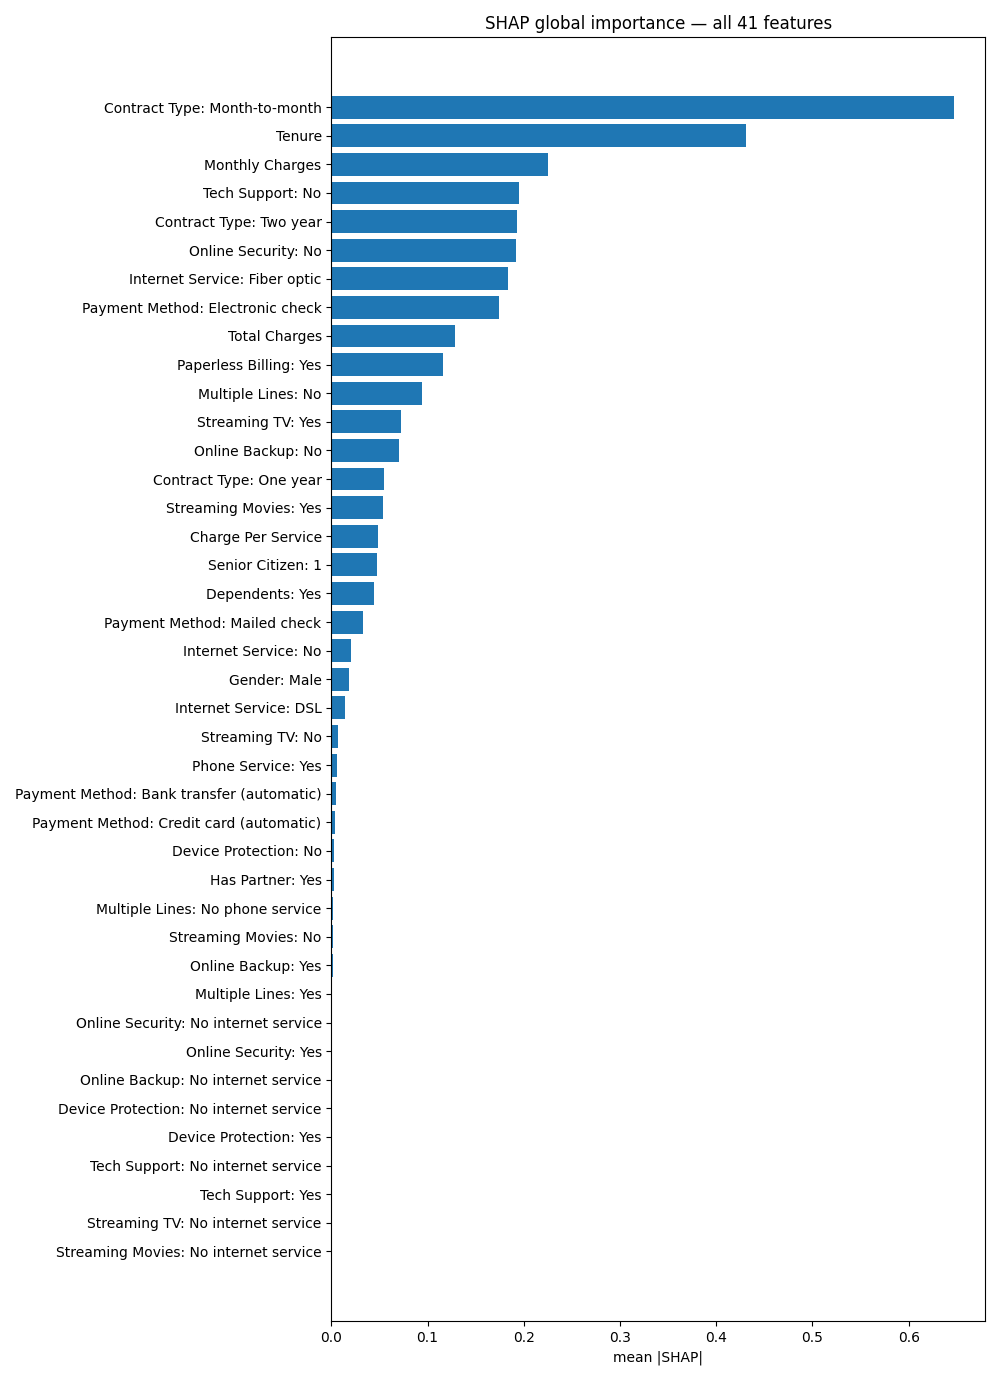

,mean_shap_at_1,mean_shap_at_0,mean_abs_shap,n_at_1,n_at_0
paperlessbilling_Yes,0.0906,-0.1493,0.1157,806,603
seniorcitizen_1,0.1583,-0.0248,0.0469,234,1175
dependents_Yes,-0.0770,0.0315,0.0444,400,1009
gender_Male,-0.0181,0.0185,0.0188,693,716
phoneservice_Yes,-0.0030,0.0284,0.0057,1256,153
has_partner_Yes,0.0014,0.0001,0.0023,704,705


In [21]:
display(Image(filename=str(figures_dir / "shap_global_importance.png")))

binary_dependence = error_analysis["shap"]["binary_dependence"]
importance_by_feature = {
    row["feature"]: row["mean_abs_shap"] for row in error_analysis["shap"]["global_importance"]
}
binary_df = pd.DataFrame(binary_dependence).T
binary_df["mean_abs_shap"] = [importance_by_feature[f] for f in binary_df.index]
binary_df.index = [name.replace("binary__", "") for name in binary_df.index]
binary_df = binary_df.sort_values("mean_abs_shap", ascending=False)
binary_df = binary_df[["mean_shap_at_1", "mean_shap_at_0", "mean_abs_shap", "n_at_1", "n_at_0"]]
display(
    binary_df.style.format(
        {
            "mean_shap_at_1": "{:.4f}",
            "mean_shap_at_0": "{:.4f}",
            "mean_abs_shap": "{:.4f}",
            "n_at_1": "{:.0f}",
            "n_at_0": "{:.0f}",
        }
    ).set_caption("Binary features — signed SHAP by level")
)

Two features carry over a third of the total signal: **Contract Type: Month-to-month** (0.65) and
**Tenure** (0.43) together make up 35% of the summed mean |SHAP| across all 41 features — the top
feature alone 1.5x the second. Both are direct levers: push month-to-month customers toward
annual/two-year contracts, and treat low tenure as the highest-risk window for outreach. A second
tier — Monthly Charges, Tech Support: No, Contract Type: Two year, Online Security: No, Internet
Service: Fiber optic, Payment Method: Electronic check — clusters at 0.17–0.22; with the top two,
these eight features explain 73% of the total, and describe one customer profile (a higher-bill
fiber subscriber without the retention add-ons, paying by a manual method) worth one bundled offer
rather than several campaigns. The remaining 9 of 41 features score exactly 0.0 — all "No internet
service" or unused add-on levels. That's not a finding: a customer without internet can't have
internet-based add-ons, so those columns never vary for anyone, and a feature that never changes has
nothing for the model to learn from.

The chart's magnitude alone can't say which way a feature pushes — a real gap for six features
(**Gender**, **Dependents**, **Senior Citizen**, **Partner**, **Phone Service**, **Paperless
Billing**) that are true 0/1 columns, not one-hot pairs, so there's no separate `Gender: Female`
feature to read a direction off. Take **Gender**: 693 male customers average **−0.018** each, 716
female customers average **+0.018** (`mean_shap_at_1` / `mean_shap_at_0`) — opposite-signed, so
they'd nearly cancel if averaged together. `mean_abs_shap` instead strips each of the 1,409
customers' own SHAP value of its sign *before* averaging, landing at **0.0188** — the bar chart's
number. Same mechanism for the other five; the beeswarm below shows the split visually and reads off
what each one means.

Demographics rank low overall — Senior Citizen, Gender, Dependents, and Partner all sit below every
product/contract/billing feature except Paperless Billing — which is itself the useful takeaway:
the levers worth building a retention strategy around are the commercial ones (contract, tenure,
services, payment), not who the customer is. That keeps the fairness question simple, too: none of
these four should ever decide *whether* a customer gets an offer, and the model's own ranking backs
that up by barely using them in the first place.

### Beeswarm — direction and magnitude together, every feature

Mean |SHAP| ranks features but collapses each one to a single number — it cannot show a feature
that pushes different customers in *opposite* directions (e.g. a numeric feature whose high and
low values argue in opposite directions) versus one that only ever pushes toward churn. The
beeswarm plots every sealed-test row's signed SHAP value for every feature, coloured by that
row's own (transformed) feature value, so both the ranking and the direction/spread are visible
at once. Same caveat as the bar chart above: computed pre-calibration, against the base LightGBM
decision function.

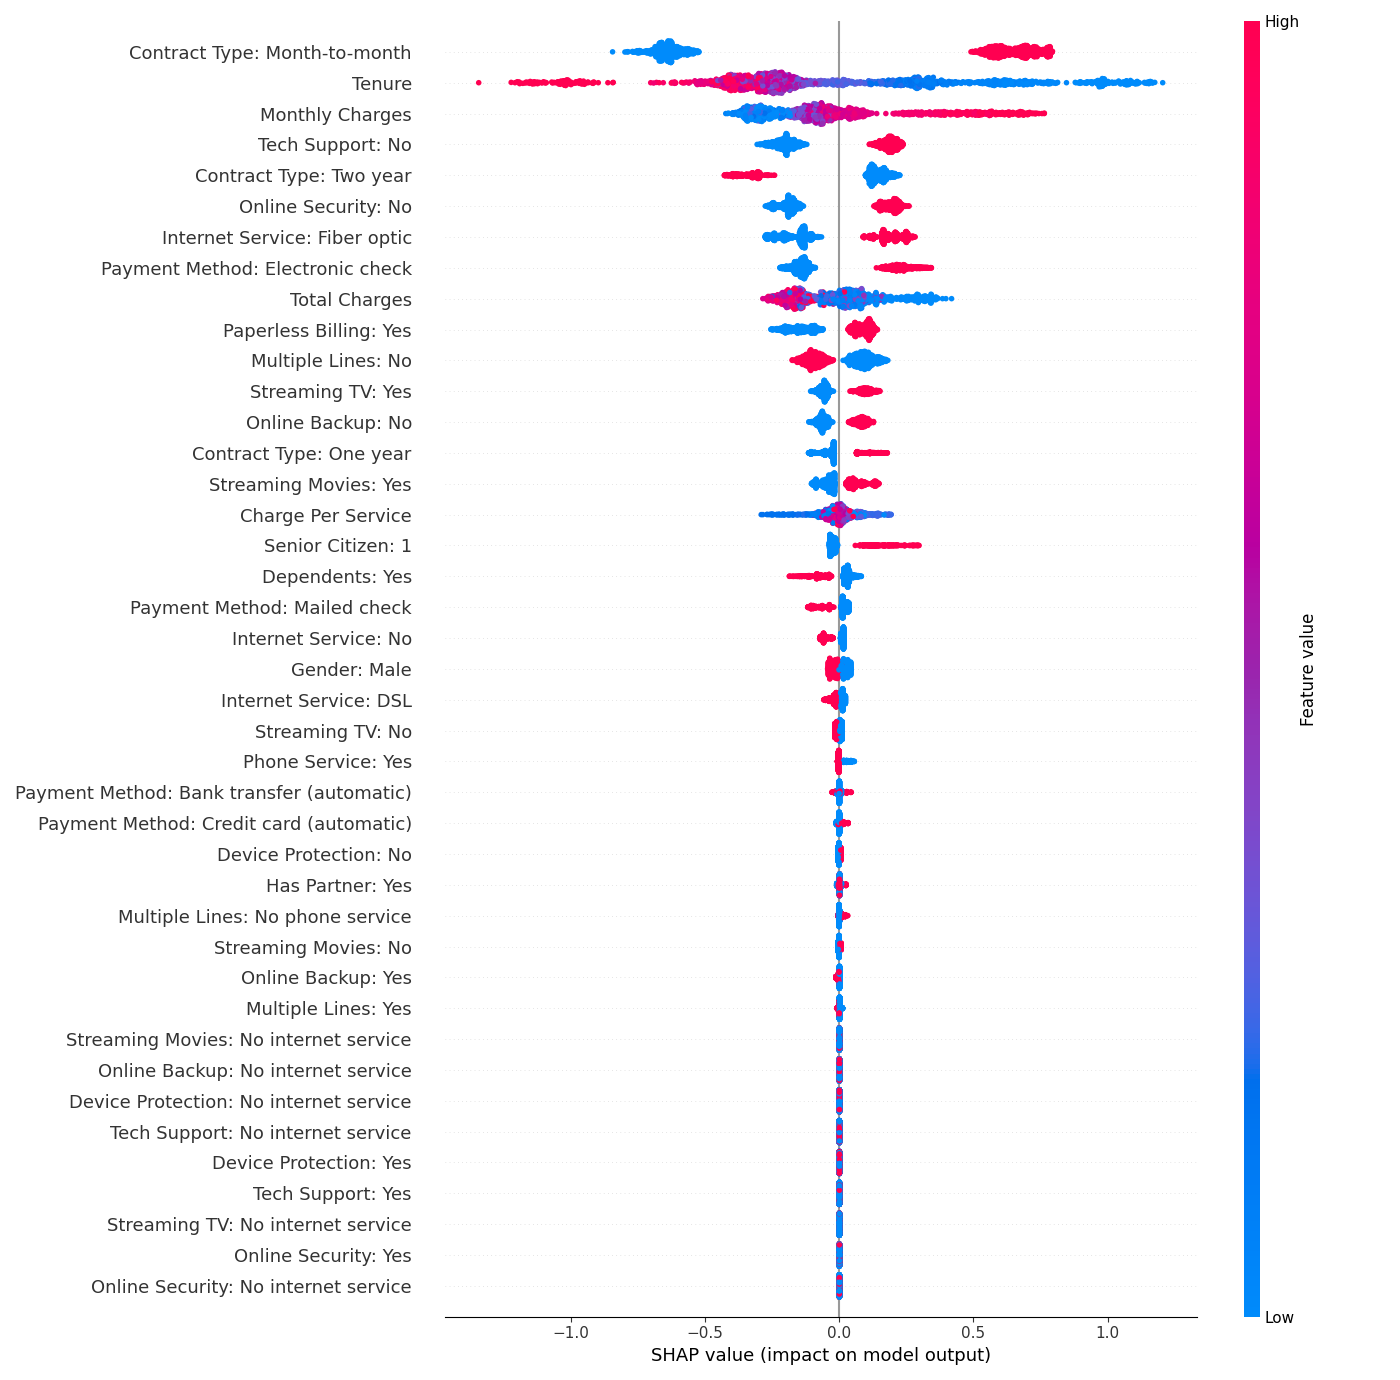

In [22]:
display(Image(filename=str(figures_dir / "shap_beeswarm.png")))

Colour marks each customer's own value for that feature (red = high or level-1, blue = low or
level-0); horizontal position marks how far that customer's score moved, and which way — right of
zero means the feature pushed toward churn, left means away from it. **Contract Type:
Month-to-month** (red) pushes toward churn; every other contract type (blue) protects. **Tech
Support: No** (red) pushes toward churn; having tech support (blue) protects. **Contract Type: Two
year** mirrors that in reverse — a two-year contract (red) protects, not having one (blue) pushes
toward churn. The direction sanity check right after this quantifies exactly how clean each of these three splits
is. **Monthly Charges** and **Tenure** point the same directions but spread more widely, since the
exact value matters, not just high vs. low: high charges (red) push toward churn, low charges
protect; long tenure (red) protects, short tenure pushes toward churn. Tenure's spread is the widest
in the chart — the single most protective customer has 71 months of tenure, the single most at-risk
customer by this feature alone has been a customer for 1 month — a wider single-customer swing than
Contract Type produces, despite ranking lower overall. That's a business point as much as a
technical one: a brand-new sign-up can be pushed further toward risk on tenure alone than almost
anyone in the dataset, the strongest case here for front-loading retention effort into a customer's
first months rather than spreading it evenly.

The same read applies to the six binary features from the table above, and each agrees with it.
Senior citizens push toward churn (**+0.158**), while non-seniors push away from it (**−0.025**).
Paperless-billing customers push toward churn (**+0.091**), while paper-billing customers push away
from it (**−0.149**). Customers without dependents push toward churn (**+0.032**), while customers
with dependents push away from it (**−0.077**) — matching the established EDA relationship. Female
customers push mildly toward churn (**+0.018**), while male customers push mildly away from it
(**−0.018**) — an order of magnitude smaller than the others. **Partner** and **Phone Service**
show red and blue overlapping near zero either way — no reliable direction to read for either. None
of these six are levers a retention team can pull directly, but they're useful for shaping outreach
rather than eligibility — a senior or paperless-billing customer the model flags may respond better
to a different message than a one-size-fits-all script.

### Direction sanity check

Does any top-8 SHAP feature's effect direction contradict the established EDA relationship (`ANALYSIS.md` §2)? A sign flip here would mean the model learned the wrong relationship for one of its most influential features — fitting an artifact, not a real pattern — and no aggregate metric like PR-AUC would ever catch it. That is exactly why the check is scoped to the top-8 by mean |SHAP|: only a flip on a feature this influential is a real red flag; the same flip on a feature the model barely uses would just be noise. Each checked feature carries an expected sign from that relationship — `+1` means a higher (or present) value is established to push *toward* churn, `-1` means it pushes *away* from it — and the model's own `observed_direction` is checked against it. Not every top-8 feature has an established relationship to check against; those are recorded below as `checked = False` rather than counted as a pass on a claim never evaluated.

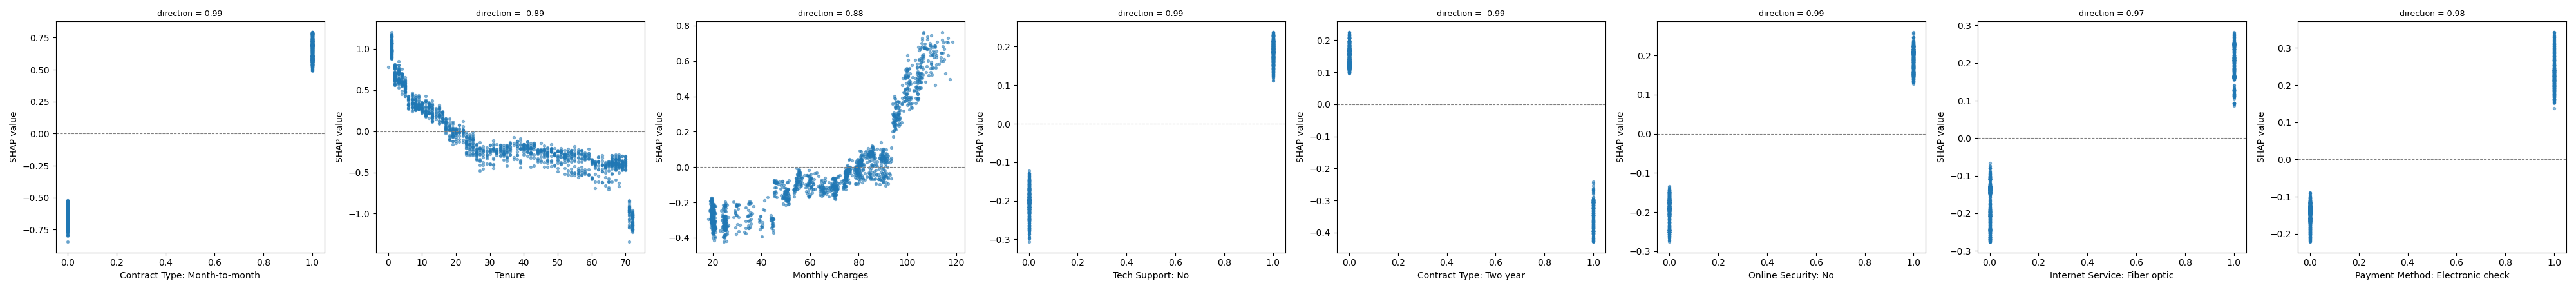

,checked,matched_eda_relationship,expected_sign,observed_direction,contradicts
feature,,,,,
Contract Type: Month-to-month,True,month-to-month,1,0.994883,False
Tenure,True,tenure,-1,-0.894208,False
Monthly Charges,True,monthlycharges,1,0.875034,False
Tech Support: No,True,techsupport_no,1,0.988235,False
Contract Type: Two year,True,two year,-1,-0.988477,False
Online Security: No,True,onlinesecurity_no,1,0.988767,False
Internet Service: Fiber optic,True,fiber optic,1,0.965993,False
Payment Method: Electronic check,True,electronic check,1,0.984354,False



Direction sanity check: PASS  (0 violation(s))


In [23]:
display(Image(filename=str(figures_dir / "shap_dependence.png")))

v3 = error_analysis["direction_sanity_check"]
v3_df = pd.DataFrame(v3["checked_features"])
v3_df["feature"] = v3_df["feature"].map(display_feature_name)
v3_df = v3_df.set_index("feature")
display(v3_df)
print(f"\nDirection sanity check: {'PASS' if v3['passed'] else 'FAIL'}  ({len(v3['violations'])} violation(s))")

The chart and table report the same number — `direction` above each subplot is
`observed_direction` in the table — with the chart showing the *shape* behind it: Tenure and
Monthly Charges are continuous and trace a real slope, while the six categorical dummies
(both Contract Type levels, Tech Support: No, Online Security: No, Internet Service: Fiber
optic, Payment Method: Electronic check) only have two x-positions, so each shows up as two
separate, non-overlapping clusters instead of a slope — not a weaker signal, in fact the
cleanest kind, which is why they post the six highest |`direction`| values in the table. All
eight agree with the established EDA direction, so none are flagged as a violation this cycle.

### Signed cohort SHAP — false negatives (FN) vs. true positives (TP), and false positives (FP) vs. true negatives (TN)

We already know the model gets two kinds of error, in opposite directions: among the
374 actual churners, it catches 261 (true positives, TP) but misses 113 (false
negatives, FN); among the 1,035 actual non-churners, it correctly leaves 856 alone
(true negatives, TN) but wrongly flags 179 (false positives, FP). This asks
*why* the model's two error types happen, by reading every SHAP value below for its
**direction** — did a feature argue "this customer will churn" or "this customer will
stay" — not just its size. FN and TP are both customers who actually churned, and FP
and TN are both customers who didn't; what separates each pair is nothing but whether
the summed SHAP push (Section 7's opening note) landed below or above `t*`, so the
comparisons below are literally mechanical, not descriptive. A feature can be highly
influential and still argue the wrong way; size alone can't distinguish a
weak-but-correct signal from a strong-but-wrong one. Each pair's bar chart below shows
only the handful of features whose average push differs most between its two cohorts,
not all 41 — a feature both cohorts agree on, however large its overall effect,
contributes nothing to explaining why one group and not the other, so including it
would only dilute the chart built to explain that gap.

#### Cohort means

One signed average per feature, per cohort — for churners, false negatives (missed)
vs. true positives (caught); for non-churners, false positives (wrongly flagged) vs.
true negatives (correctly ignored). Each pair gets its own independently-derived
cutoff — seven features for FN/TP, nine for FP/TN — since each ranks a different
quantity (|FN − TP| vs. |FP − TN| gap) with its own plateau shape, not the same list
at two lengths.


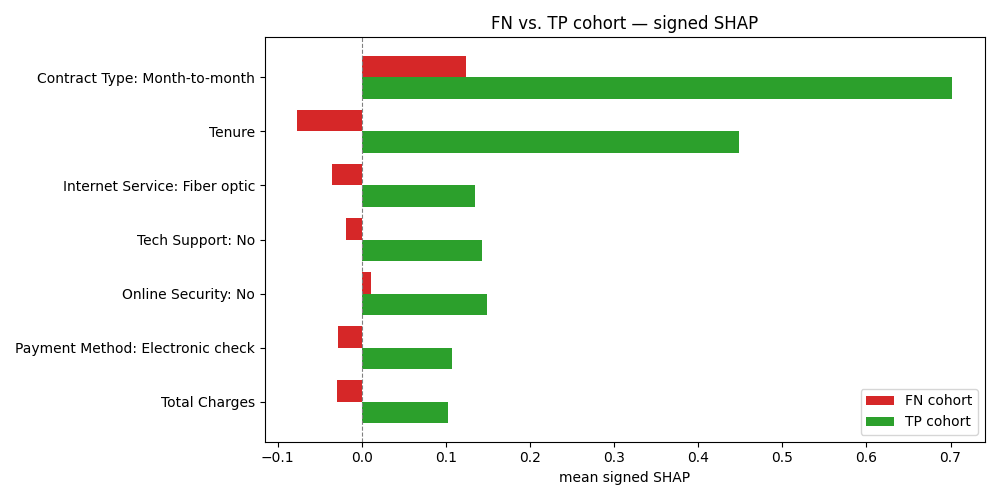
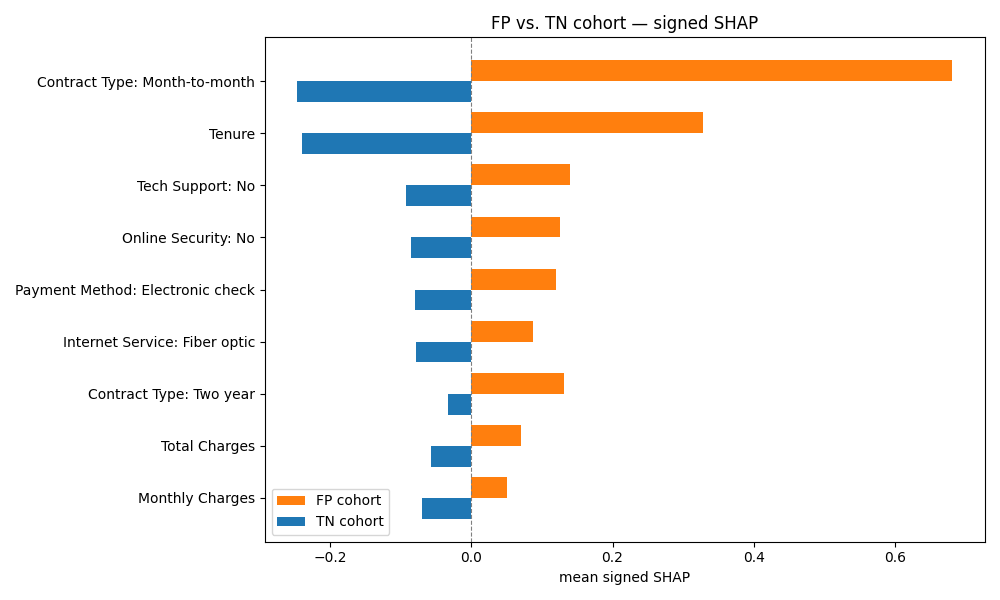

In [24]:
fn_tp_bar_b64 = base64.b64encode(
    (figures_dir / "shap_cohort_fn_vs_tp.png").read_bytes()
).decode("ascii")
fp_tn_bar_b64 = base64.b64encode(
    (figures_dir / "shap_cohort_fp_vs_tn.png").read_bytes()
).decode("ascii")

display(
    HTML(
        '<div style="display:flex; align-items:flex-start; gap:24px; flex-wrap:wrap;">'
        '<div style="flex:1 1 45%; min-width:320px;">'
        f'<img src="data:image/png;base64,{fn_tp_bar_b64}" style="max-width:100%;"></div>'
        '<div style="flex:1 1 45%; min-width:320px;">'
        f'<img src="data:image/png;base64,{fp_tn_bar_b64}" style="max-width:100%;"></div>'
        "</div>"
    )
)

False negatives are a **dilution** problem: the features that argue "churn" strongly
for true positives (Contract Type: Month-to-month +0.70, Tenure +0.45) argue it barely
at all for the customers the model misses. Even the strongest, Month-to-month, drops to
just +0.12, and five of the seven tip slightly negative — but every one stays within
about ±0.13 of zero, nowhere near enough to mean "the model read this customer as
safe." The signal hasn't reversed; it's gone quiet.

False positives are a **collision** problem, and fail the opposite way: the same
features argue "churn" for false positives almost as strongly as they do for real
churners (Month-to-month +0.68 vs. TP's +0.70; Tenure +0.33 vs. +0.45), while true
negatives argue solidly the other way (−0.25, −0.24, the rest between −0.03 and
−0.09). These 179 false alarms aren't borderline cases nudged over `t*` — on every
feature the model relies on most, they look like real churners.

Neither is something the shipped threshold can fix — consistent with the confidence
analysis above, both are feature problems, not threshold problems: moving `t*` only
trades between error types along the existing ranking, and here the ranking itself is
what's off. Closing either gap needs a feature this model doesn't have — most plausibly
a loyalty or satisfaction signal — not a threshold or calibration change. Until then,
both are a structural cost of the current feature set: some retention spend goes to
customers who were never leaving, and some real churners never get flagged at all.

#### Cohort beeswarms

Every feature's push adds up to one customer's total score, and that total, checked
against `t*`, is what decides false negative vs. true positive, or false positive vs.
true negative — not any single feature alone. The means above report one number per
feature, per cohort; this is the individual-level check behind that number: did
*every* customer in the cohort push toward the same total, or did some push hard one
way and others hard the other way, cancelling out to a mean that looks smaller than
any real customer's own experience? The grid below is built to be read side by side:
top row is false negatives next to true positives, bottom row is false positives next
to true negatives, so each error sits directly against the correct prediction it's
measured against. Each dot is one customer's push for one feature, colored by that
customer's own value, as in the full-population beeswarm above.


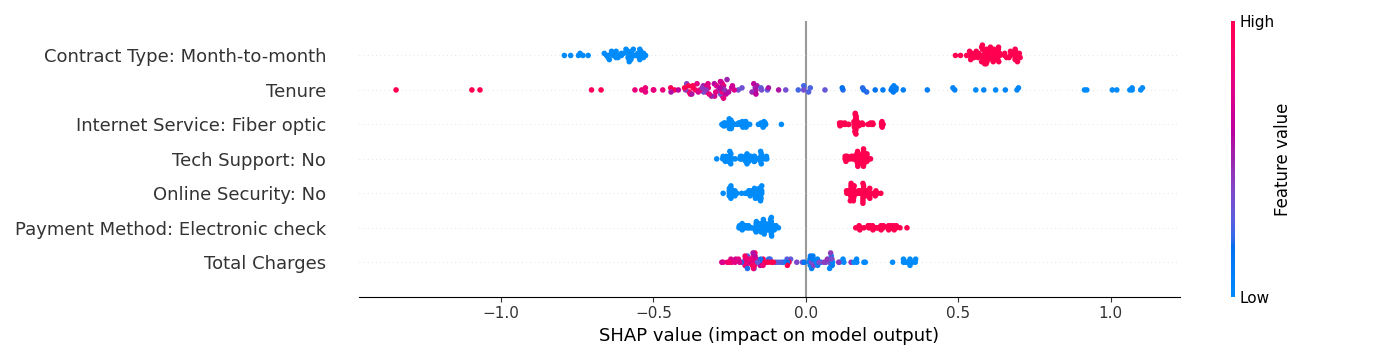
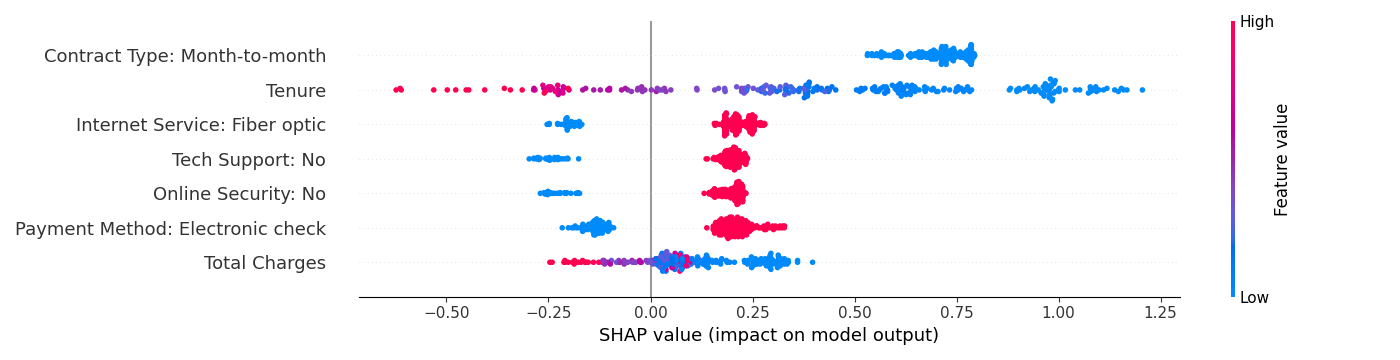
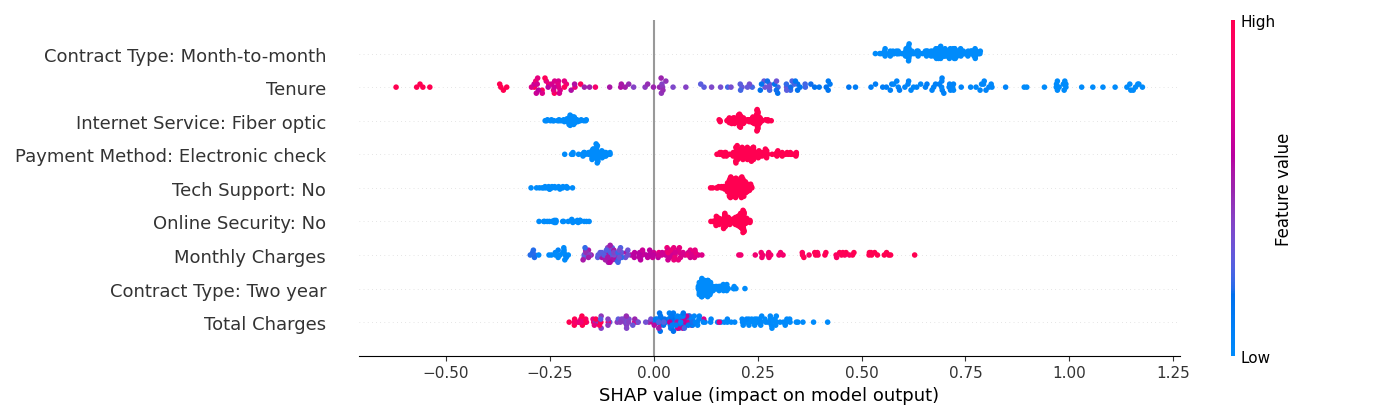
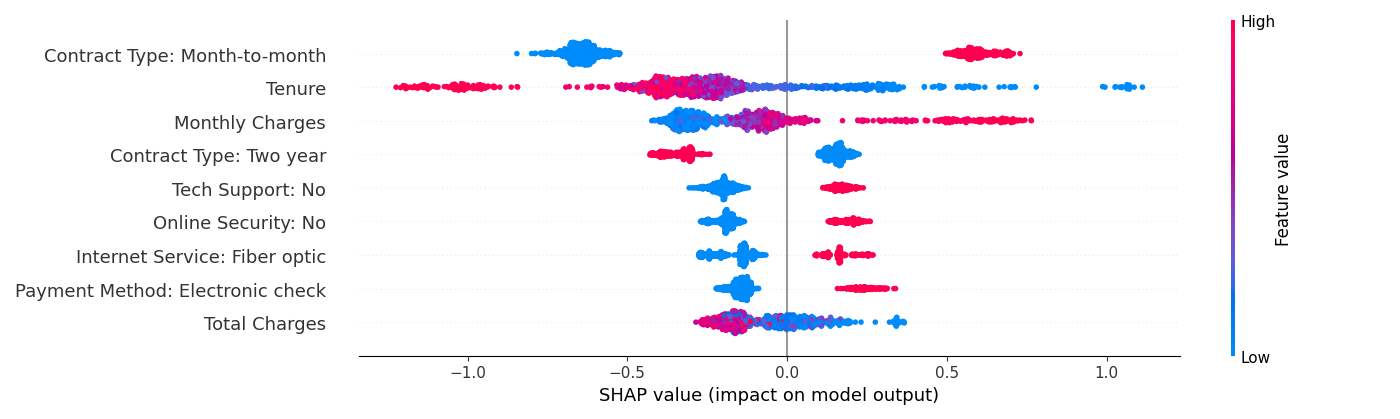

In [25]:
fn_beeswarm_b64 = base64.b64encode(
    (figures_dir / "shap_cohort_beeswarm_fn.png").read_bytes()
).decode("ascii")
tp_beeswarm_b64 = base64.b64encode(
    (figures_dir / "shap_cohort_beeswarm_tp.png").read_bytes()
).decode("ascii")
fp_beeswarm_b64 = base64.b64encode(
    (figures_dir / "shap_cohort_beeswarm_fp.png").read_bytes()
).decode("ascii")
tn_beeswarm_b64 = base64.b64encode(
    (figures_dir / "shap_cohort_beeswarm_tn.png").read_bytes()
).decode("ascii")

display(
    HTML(
        '<div style="display:grid; grid-template-columns:1fr 1fr; gap:16px;">'
        '<div><p><b>False negatives (missed churners)</b></p>'
        f'<img src="data:image/png;base64,{fn_beeswarm_b64}" style="max-width:100%;"></div>'
        '<div><p><b>True positives (caught churners)</b></p>'
        f'<img src="data:image/png;base64,{tp_beeswarm_b64}" style="max-width:100%;"></div>'
        '<div><p><b>False positives (false alarms)</b></p>'
        f'<img src="data:image/png;base64,{fp_beeswarm_b64}" style="max-width:100%;"></div>'
        '<div><p><b>True negatives (correctly ignored)</b></p>'
        f'<img src="data:image/png;base64,{tn_beeswarm_b64}" style="max-width:100%;"></div>'
        "</div>"
    )
)

Set against the true-positive panel, false negatives split into two different
reasons for staying below `t*` — and one of them has no true-positive counterpart at
all. The true-positive panel's Contract Type row is a single cluster, all
month-to-month; the model has essentially never caught a churner who wasn't. So the
40% of false negatives on annual or two-year contracts, pushing a genuine −0.61
toward "stay," have nothing to be checked against directly — they're missed largely
because this profile barely exists among the churners the model does catch. The
other 60%, month-to-month, are where the panels compare directly: they push a real
+0.61 toward "churn," nearly matching the true-positive panel's own +0.70, but not
quite enough once every other feature is added in. Average the two and the result is
the deceptively small +0.12 the means reported — two real, opposite-strength pulls
landing on either side of zero, not 113 muted signals. The four remaining
categorical features (Internet Service, Tech Support, Online Security, Payment
Method) trail the true-positive panel the same way, just smaller — 9-22% softer —
except Payment Method, which runs slightly stronger; either way, not enough to close
the gap.

False positives, set against the true-negative panel, show no split at all: every
one of the 179 is month-to-month, pushing +0.68 toward "churn" — nearly matching the
true-positive panel's own +0.70. Contract Type: Two year and the four remaining
categorical features confirm it: every false-positive dot pushes as hard as true
negatives' own at-risk dots do, no exceptions. No cancelling, no mix of strong and
weak — every feature argues "churn" about as hard as it does in the true-positive
panel, which is exactly why the total crosses `t*` for a customer who was never
going to leave.

That split matters for what a fix would actually look like. The month-to-month share
of false negatives and the entire false-positive cohort are the same problem — a
feature that measures loyalty or satisfaction directly, not just contract length or
tenure, would help separate a genuine risk from a look-alike. The annual-contract
share is different, and better news than "carries every signal this model treats as
safe" suggests: an existing feature (Monthly Charges) already separates them from
genuinely loyal customers, and the model reacts to it — just not strongly enough to
outweigh Contract Type. A weighting problem, not a missing-feature one, and a cheaper
one to fix.

#### Cohort dependence — Tenure

A SHAP dependence plot shows how a feature's contribution to the score changes
across its own range — usually colored by a second feature to reveal an
interaction; here, colored by outcome (FN/TP/FP/TN) instead, to check whether the
model treats the same tenure value differently for a miss than for a catch. Tenure
is the only feature suited to this: continuous (0–72 months), so a scatter traces a
real curve, unlike a 0/1 feature such as Contract Type. This is the *where* behind
the dilution and collision already found — do the cohorts get treated differently
at the same tenure value, or do they just have different tenure values?

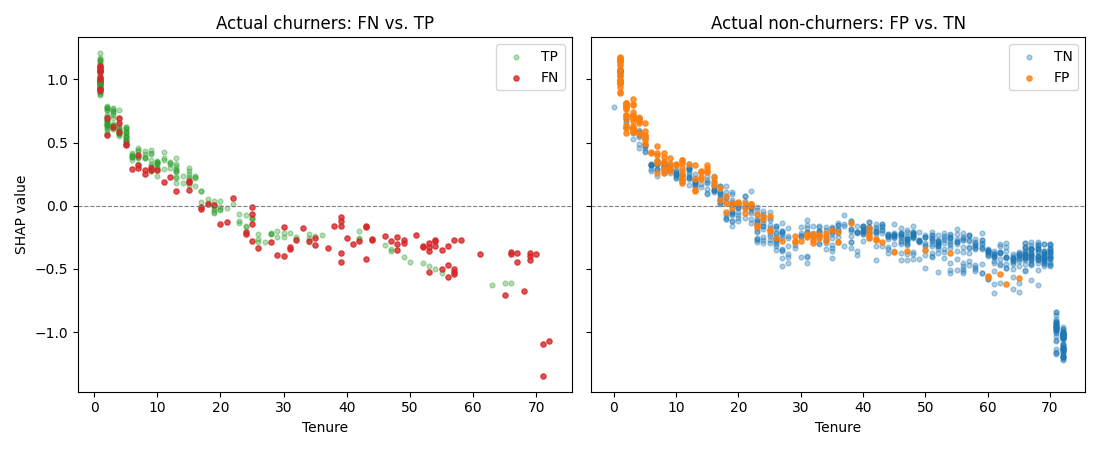

In [26]:
display(Image(filename=str(figures_dir / "shap_cohort_dependence_tenure.png")))

Both panels trace the same curve for both cohorts, not two different curves —
tenure pushes every customer the same way at the same tenure value; the cohorts
diverge in *which* tenure values they're drawn from, not in how the model treats a
given one. False negatives sit at a mean tenure of 34 months, three times true
positives' 11 — missed churners who, by tenure alone, looked like some of the
safest customers in the book. False positives run the opposite way: 15 months
against true negatives' 42 — false alarms drawn from exactly the new-customer
population tenure is supposed to flag, who simply didn't churn. The business
finding: tenure-based prioritization — focus retention on new sign-ups,
deprioritize long-tenure customers — is right on average but wrong at both tails,
and closing either gap needs a genuine loyalty or satisfaction signal, not a
longer or shorter tenure cutoff — with one exception: Monthly Charges closes part
of the gap for annual-contract false negatives specifically, just not enough on
its own. Long tenure doesn't guarantee a customer stays; short tenure doesn't
guarantee they'll leave.

#### Subgroup dependence — Monthly Charges (annual-contract customers)

Contract type explained why false negatives split into two groups; this asks
whether Monthly Charges does the same for the harder-to-catch group — customers
already on an annual or two-year contract. Restricted to exactly that comparison:
false negatives against true negatives, both on a long-term contract, to see if
spend reveals what contract type and tenure alone couldn't.

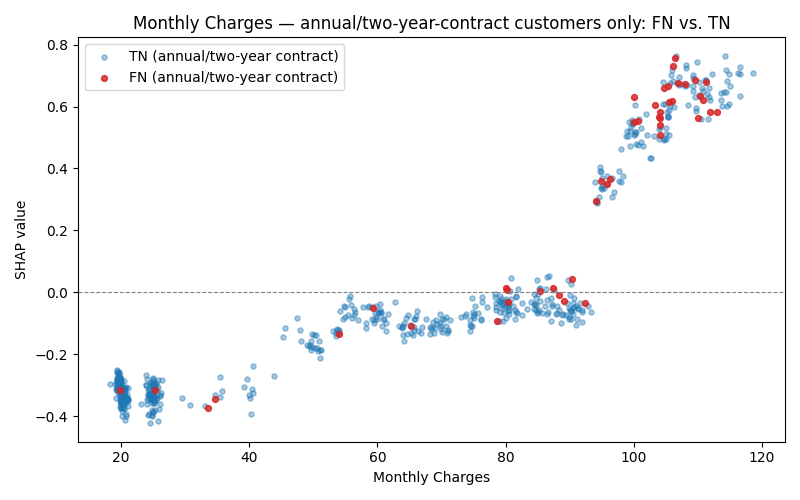

n (FN, annual/2yr)         : 45
n (TN, annual/2yr)         : 584
Median Monthly Charges FN  : $100.00
Median Monthly Charges TN  : $61.48
Mean SHAP push FN          : +0.3211
Mean SHAP push TN          : -0.0420
Mann-Whitney p (FN > TN)   : 6.06e-10


In [27]:
display(Image(filename=str(figures_dir / "shap_subgroup_dependence_monthlycharges_annual.png")))

mc = error_analysis["subgroup_findings"]["annual_contract_fn_vs_tn_monthlycharges"]
print(f"n (FN, annual/2yr)         : {mc['n_fn']}")
print(f"n (TN, annual/2yr)         : {mc['n_tn']}")
print(f"Median Monthly Charges FN  : ${mc['fn_median']:.2f}")
print(f"Median Monthly Charges TN  : ${mc['tn_median']:.2f}")
print(f"Mean SHAP push FN          : {mc['fn_mean_shap']:+.4f}")
print(f"Mean SHAP push TN          : {mc['tn_mean_shap']:+.4f}")
print(f"Mann-Whitney p (FN > TN)   : {mc['mannwhitney_p_fn_greater']:.2e}")

Monthly Charges behaves exactly like Tenure: the model treats a $100-a-month
customer the same way whether they're a false negative or a true negative — most
missed churners pay $80 or more (some over $110), while genuinely loyal customers
on the same contract spread across the full $20–120 range, a gap too large and
consistent to be chance. This corrects an earlier claim in this notebook: saying
annual-contract false negatives "look completely safe" was wrong — Monthly
Charges argues "this customer will churn" for them almost as loudly as it does
for true positives, and the model listens, it's just outvoted by Contract Type's
roughly twice-as-strong pull the other way. That's two fixes on two timelines, not
one: today, with no engineering work, flag long-contract customers whose monthly
bill sits in the top 25% for retention outreach by hand — a spreadsheet filter,
not a model change. Longer term, it's a real modelling opportunity too: an
engineered interaction feature (spend × contract length) or a reweighted refit
could let the model itself catch these customers next cycle, without needing any
new data collection — unlike the tenure/loyalty gap above, which does need a
genuinely new signal.

### Illustrative cases — anecdotal only

A handful of real, individual customers, shown as SHAP waterfall charts — the
same "most confidently wrong" missed churners and false alarms discussed above,
plus one clear correct catch and one clear correct pass for direct comparison.
Each bar shows how much one feature pushed that customer's risk score up or down,
starting from the model's average output (`E[f(x)]`) and ending at their actual
score (`f(x)`); the bars add up exactly to that difference, so this is a literal
accounting of the prediction, not just a list of important features. **Strictly
illustrative** — one customer is an anecdote, never evidence on its own — these
exist only to make the findings above concrete: does a false positive's chart
really look like a true positive's, or does the prose just say so?

#### Missed churners and false alarms

The three most confidently-missed false negatives, and the three most
confidently over-flagged false positives — the same cases the cohort-level
findings above were built to explain, now shown one customer at a time.

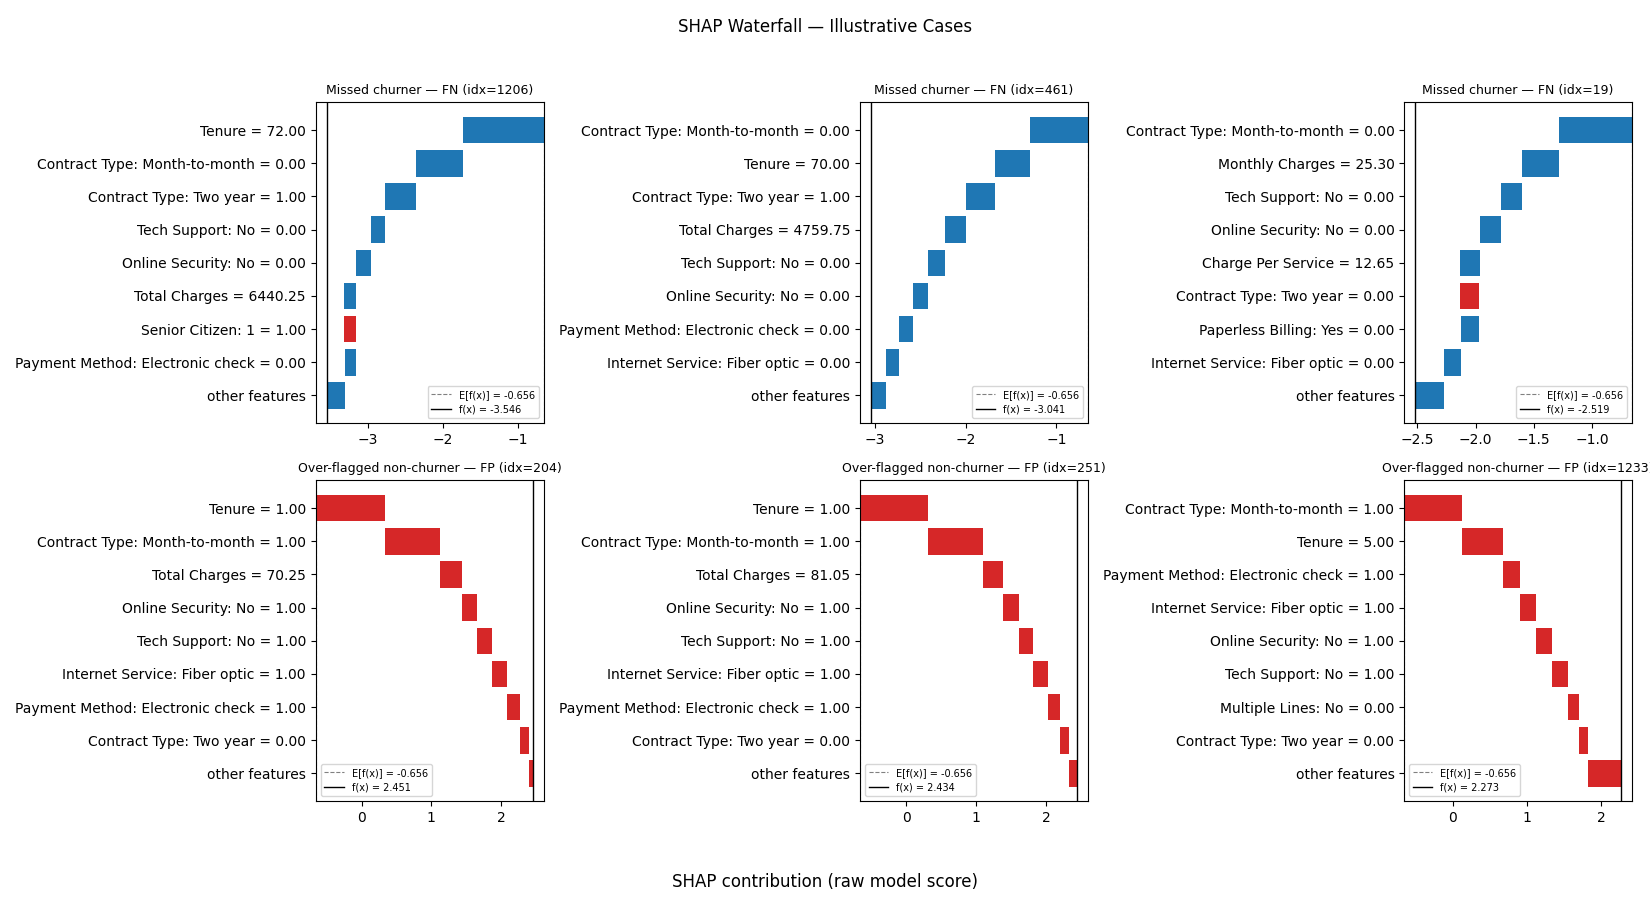

In [28]:
display(Image(filename=str(figures_dir / "shap_waterfall_examples.png")))

**Missed churners.** idx=1206 (72 months, two-year contract, tech
support and online security both in place, $92.45/month) and idx=461
(70 months, two-year contract, tech support and online security both in
place, $65.30/month) are two of the three false negatives, and both
look safe on tenure and contract type — the same read a spreadsheet
skim would give. But idx=1206 is also paying $92.45 a month, and that's
the pattern this notebook already found in aggregate: annual-contract
customers who pay more are quietly more likely to be missed, because
the model does react to a higher bill, just not enough to outweigh
Contract Type's much stronger pull toward "safe." Its only other
churn-leaning signal is Senior Citizen status — and together they still
aren't enough: the model rates this customer −3.5, one of its most
confidently "safe" scores in the set (negative means the model reads
low risk, positive means high risk, and the further from the middle,
the more confident the call). This pay-more-but-still-missed pattern is
the first of two distinct failure shapes among the missed churners
here — and it's the one retention can already act on today, by
flagging long-contract customers with high bills for manual outreach.

idx=19 is the other shape, and doesn't fit at all: a phone-only
customer with no internet service, one-year contract, 25 months of
tenure, $25.30/month. Almost all of the model's warning signs are
internet-service features — tech support, online security, fiber — so
a customer with no internet doesn't trip any of them, and its −2.5
score comes almost entirely from contract type and low spend instead.
One customer is an anecdote, not a pattern, but it points at a real
structural gap: phone-only customers stay close to invisible to this
model, regardless of tenure or contract. Unlike the
pay-more-but-still-missed pattern above, this one needs new
engineering, not a targeting rule.

**False alarms.** All three false positives are close to identical:
idx=204, idx=251, and idx=1233 are one-to-five-month-old,
month-to-month, fiber-optic, electronic-check, no-security, no-support
customers, all scored confidently "risky" on the same scale (+2.3 to
+2.5) — and none of them left. This is the same new/unprotected
profile the tenure findings above flagged as the model's highest-risk
signature; it isn't wrong to flag it, it's just early — and it costs
far less than a missed churner either way: flagging three
high-risk-looking new customers who happened to stay is a wasted
outreach call, not a lost customer, exactly the asymmetry the shipped
threshold is built to accept.

#### Confident cases, for comparison

The single most-confident true positive and true negative, drawn with the
identical waterfall used for every FN/FP case above — a direct, same-format check
on the cohort-level dilution and collision findings, not a new analysis.

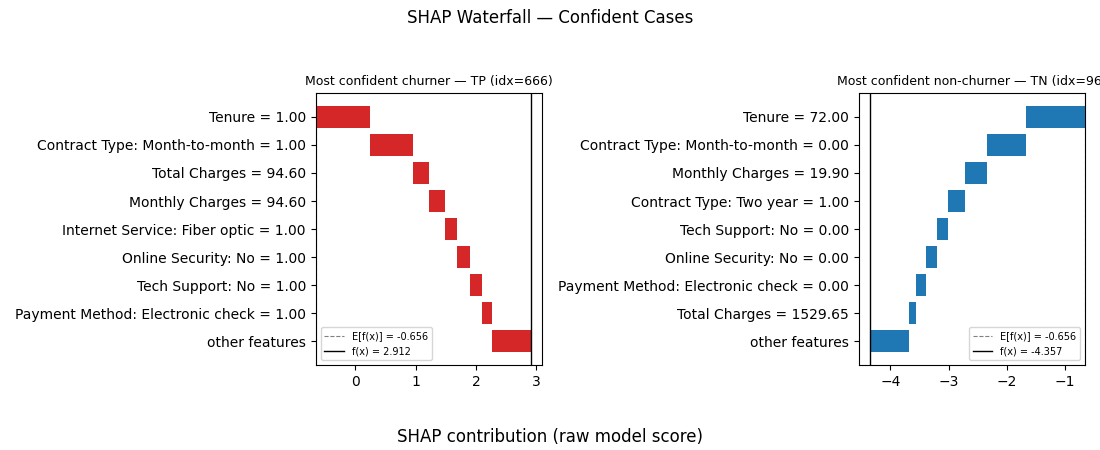

In [29]:
display(Image(filename=str(figures_dir / "shap_waterfall_confident_cases.png")))

**Confirmed catch.** idx=666 (the most confident true positive,
`f(x)`=2.91) is a brand-new, month-to-month, fiber-optic subscriber with
high monthly and total charges ($94.60 each), no security or support
add-ons — the same kind of profile every false-positive waterfall above
shows, except this time the customer really did leave.

**Confirmed safe.** idx=96 (the most confident true negative,
`f(x)`=−4.36) is a closer match still to the false negative above:
tenure, both contract-type markers, tech support, online security, and
payment method are all identical to idx=1206's missed churner — six of
eight bars, down to the same tenure value. The seventh shared feature,
Total Charges, tells the same story a different way: $6,440 for idx=1206
against $1,530 for idx=96, over the identical 72 months — the same
$92-versus-$20-a-month gap measured earlier across all 45 annual-contract
customers, now visible in two real bills. idx=1206 and idx=96 are
effectively twins on every loyalty signal the model has — tenure,
contract, add-ons — and the one real difference is a bill
four-and-a-half times bigger; a model that treats two otherwise-identical
customers differently because of that gap isn't guessing, it's using the
one signal that actually separates them.

## 8. Human review — model risk sign-off

**Veto-only checkpoint: approve or reject, not iterate.** Editing the
model now means re-touching the sealed test set, so a genuine problem
means **reject** and a return to feature engineering and retraining —
not a fix in place. PR-AUC, recall, Brier skill score, and calibration
slope already passed automatically in Section 2; checked fresh here (Sections 5 and 7
above) are the direction sanity check (clean) and the fairness gap — flagged for
`seniorcitizen`, `has_partner`, `dependents`, consistent with genuinely higher churn risk
in this context rather than proxy discrimination, so it's tracked, not blocking. Segment
collapse and per-group calibration collapse (V1/V2b) were already checked on dev-OOF in
[`04-calibration-and-threshold.ipynb`](04-calibration-and-threshold.ipynb) (§4) — both
clean — and aren't re-derived here. The checkbox below only reflects the direction check;
the approve/reject call is set separately, by `verdict`.

In [30]:
# --- Reviewer inputs — edit before running if your judgment differs ---
verdict = "approved"  # "approved" | "rejected"
approver = "Richlove Frimpong"
notes = (
    "All four automated gate criteria pass (PR-AUC 0.670 vs 0.60 bar; recall 0.698 vs 0.65 bar; "
    "BSS 0.301; calibration slope 0.992, CI clears [0.80, 1.25]). The direction sanity check "
    "(the sole binding criterion, scoped to the top-8 |SHAP| features) shows no violations. "
    "The segment-collapse and per-group calibration checks (V1/V2b), run on dev-OOF by threshold.py's pre-seal screen (04-calibration-and-threshold.ipynb §4), report no flags. The "
    "fairness-disparity check fires on seniorcitizen/has_partner/dependents: these groups are "
    "contacted at a higher rate and have a lower false-negative rate, consistent with "
    "genuinely higher churn risk in a benefit-allocation (retention outreach) context rather "
    "than proxy discrimination against a near-zero-signal attribute (gender's own gap is "
    "small). Documented for the model card and flagged for ongoing production monitoring "
    "— these are reported diagnostics, not conditions of promotion."
)
reviewed_at = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")

direction_sanity_check_fired = len(error_analysis["direction_sanity_check"]["violations"]) > 0

reviewed_decision = record_review(
    promotion_decision,
    verdict=verdict,
    notes=notes,
    approver=approver,
    reviewed_at=reviewed_at,
    direction_sanity_check_fired=direction_sanity_check_fired,
)

with open(reports_dir / "promotion_decision.json", "w", encoding="utf-8") as f:
    json.dump(reviewed_decision, f, indent=2, default=str)

mlflow.tracking.MlflowClient().log_dict(
    promotion_decision["eval_run_id"], reviewed_decision, "promotion_decision.json"
)

print(f"Recorded review: {reviewed_decision['review']} by {reviewed_decision['approver']} at {reviewed_decision['reviewed_at']}")
print(f"Direction sanity check fired: {reviewed_decision['direction_sanity_check_fired']}")
print(f"Logged to MLflow run {promotion_decision['eval_run_id']}: promotion_decision.json (reviewed)")

Recorded review: approved by Richlove Frimpong at 2026-07-28 19:10:56 UTC
Direction sanity check fired: False
Logged to MLflow run 5d08981c0c12442ebf767c5e106a6842: promotion_decision.json (reviewed)


## Summary

The champion candidate clears the promotion gate on all four criteria: PR-AUC 0.670 (bar 0.60),
recall 0.698 (bar 0.65), a positive Brier skill score (0.301), and a calibration slope of 0.992
(CI clears [0.80, 1.25]). The direction-sanity check (this notebook) and the segment/per-group calibration
collapse checks (dev-OOF, `04-calibration-and-threshold.ipynb` §4) are all clean. A fairness gap flags three groups (`seniorcitizen`, `has_partner`, `dependents`) —
consistent with those customers genuinely churning more, not the model discriminating — so
it's tracked going forward rather than blocking this promotion.

The SHAP analysis surfaces one real signal gap and two fixable patterns. The gap: tenure and
new-signup status aren't reliable stand-ins for loyalty, and closing it needs a genuine loyalty
or satisfaction signal this dataset doesn't have — not a different cutoff. The patterns:
annual-contract customers with high bills are quietly missed almost as often as flagged
churners (fixable today with manual outreach targeting, and properly next cycle with an
interaction feature or reweighted refit), and phone-only customers sit almost entirely outside
the model's current signals (needs new engineering, not a targeting rule). False positives cost
far less than a missed churner either way, which is why the shipped threshold is willing to
accept more of them to catch more real churners.

Every number here comes from one scoring pass — `models/evaluate.py` and
`models/error_analysis.py` — and nothing is recomputed in this notebook. The verdict recorded
below is what `models/register.py` requires before the model is promoted. Full
narrative: **[§0 Problem Framing & Cost Definition](../ANALYSIS.md#0-problem-framing--cost-definition)**
and **[§7 Final Test-Set Results](../ANALYSIS.md#7-final-test-set-results)** in
`ANALYSIS.md`.